# DISCLAIMER:
Even though there are some comments on this notebook, the complete analysis of the problem and its results are on a PowerPoint presentation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

# CONSTANTS

$G=6.67 \times 10^{-8} \ \rm{cm}^3 \ \rm{g}^{-1} \ \rm{s}^{-2}$ 

$c=3 \times 10^{10} \ \rm{cm} \ \rm{s}^{-1}$

$\kappa_{\rm{es}}=0.34 \ \rm{cm}^2 \ \rm{g}^{-1}$

$\kappa_0=6.4 \times 10^{22} \ \rm{cm}^5 \ \rm{g}^{-2} \ \rm{K}^{7/2}$

$\mu=0.6$ - Fully Ionised Gas

$m_p=1.67 \times 10^{-24} \ \rm{g}$

$\sigma=5.67 \times 10^{-5} \ \rm{erg} \ \rm{cm}^{-2} \ \rm{s}^{-1} \ \rm{K}^{-4}$

$a=7.56 \times 10^{-15} \ \rm{erg} \ \rm{cm}^{-3} \ \rm{K}^{-4}$

$k=1.38 \times 10^{-16} \ \rm{erg} \ \rm{K}^{-1}$

$M_{\odot}=2 \times 10^{33} \ \rm{g}$

$\eta=1-\frac{\sqrt{8}}{3} \approx 0.057$ - Accretion Rate for a Schwarzschild Black Hole

$\sigma_T=6.652 \times 10^{-25} \ \rm{cm}^2$

$h=6.626 \times 10^{-27} \ \rm{erg} \ \rm{s}$

In [2]:
# CGS UNITS
G=6.67e-8
c=3e10
kes=0.34
k0=6.4e22
mu=0.6 
mp=1.67e-24
sigma=5.67e-5
a=4*sigma/c
k=1.38e-16
Msun=2e33
eta=1-np.sqrt(8)/3 
sigmaT=6.652e-25
h_planck=6.626e-27

# FUNCTIONS

In [3]:
def f(R,Rstar):
    return 1-np.sqrt(Rstar/R)

def OmegaK(R,M):
    return np.sqrt(G*M/R**3)

def Qplus(R,Rstar,M,Mdot):
    return (3*G*M*Mdot*f(R,Rstar))/(4*np.pi*R**3)

In [4]:
def initial_guess(R,Rstar,M,Mdot,alpha):
    Tc=( (Qplus(R,Rstar,M,Mdot)*kes*Mdot*f(R,Rstar)*mu*mp*OmegaK(R,M)) / (8*np.pi*sigma*alpha*k) )**(1/5)
    H=1/OmegaK(R,M) * np.sqrt(k/(mu*mp) *Tc)
    Sigma=(Mdot*f(R,Rstar))/(3*np.pi*alpha*OmegaK(R,M)) * 1/H**2
    rho_c=Sigma/(2*H)

    if R==Rstar:
        return np.array([0.0,0.0,0.0,0.0])
    return np.array([Sigma,Tc,H,rho_c])

In [5]:
def F(xk,R,Rstar,M,Mdot,alpha):
    Sigma,Tc,H,rho_c = xk

    f1=3*Qplus(R,Rstar,M,Mdot)*kes*Sigma + 3*Qplus(R,Rstar,M,Mdot)*Sigma*k0*rho_c*Tc**(-7/2) -8*sigma*Tc**4
    f2=3*Sigma*k*Tc + 2*a*Tc**4*H*mu*mp -3*mu*mp*H**2*OmegaK(R,M)**2*Sigma
    f3=3*np.pi*Sigma*alpha*OmegaK(R,M)*H**2 - Mdot*f(R,Rstar)
    f4=2*rho_c*H-Sigma

    return [-f1,-f2,-f3,-f4]

In [6]:
def Jacobian(xk,R,Rstar,M,Mdot,alpha):
    Sigma,Tc,H,rho_c = xk

    J=[[0.,0.,0.,0.],[0.,0.,0.,0.],[0.,0.,0.,0.],[0.,0.,0.,0.]]

    J[0][0]=3*Qplus(R,Rstar,M,Mdot)*(kes+k0*rho_c*Tc**(-7/2))
    J[0][1]=-21/2*Qplus(R,Rstar,M,Mdot)*Sigma*k0*rho_c*Tc**(-9/2)-16*sigma*Tc**3
    J[0][2]=0
    J[0][3]=3*Qplus(R,Rstar,M,Mdot)*Sigma*k0*Tc**(-7/2)

    J[1][0]=3*k*Tc-3*mu*mp*H**2*OmegaK(R,M)**2
    J[1][1]=3*Sigma*k + 8*a*Tc**3*H*mu*mp
    J[1][2]=2*a*Tc**4*mu*mp - 6*mu*mp*H*OmegaK(R,M)**2*Sigma
    J[1][3]=0

    J[2][0]=3*np.pi*alpha*OmegaK(R,M)*H**2
    J[2][1]=0
    J[2][2]=6*np.pi*Sigma*alpha*OmegaK(R,M)*H
    J[2][3]=0

    J[3][0]=-1
    J[3][1]=0
    J[3][2]=2*rho_c
    J[3][3]=2*H

    return J 

In [7]:
def Gauss_Jordan(A,b):
    n=len(A)
    C=[A[i]+[b[i]] for i in range(n)]
    eps=1e-15  
    
    for i in range(n):
        max_row=i
        for r in range(i+1,n):
            if np.abs(C[r][i]) > np.abs(C[max_row][i]):
                max_row = r
                
        if max_row!=i:
            C[i],C[max_row]=C[max_row],C[i]
            
        if np.abs(C[i][i])<eps:
            return [0]*n

        diag=C[i][i]
        for c in range(i,n+1):
            C[i][c]/=diag
            
        for r in range(n):
            if r!=i:
                mult=C[r][i]
                for c in range(i,n+1):
                    C[r][c]-=mult*C[i][c]
                    
    return [row[-1] for row in C]

In [8]:
def new_step_log(yk,R,Rstar,M,Mdot,alpha):
    xk=np.exp(yk)
    F_val=F(xk,R,Rstar,M,Mdot,alpha)
    J=np.array(Jacobian(xk,R,Rstar,M,Mdot,alpha))
    logJ=J*xk
    delta_yk=Gauss_Jordan(logJ.tolist(),F_val)
    return delta_yk

In [9]:
def P(Tc,rho_c):
    Pgas=rho_c*k*Tc/(mu*mp)
    Prad=a/3*Tc**4
    return Pgas, Prad

In [10]:
def Luminosity(M,Mdot,Rstar):
    return G*M*Mdot/2/Rstar

$$
\frac{dL}{dlnR}=2 \pi R^2 Q^+(R) \rightarrow \int dL=2 \pi \int R Q^+(R) dR \rightarrow L=\frac{GM\dot{M}}{2R_*}
$$

In [11]:
def dL_dR(R,Rstar,M,Mdot):
    return 2*np.pi*R*Qplus(R,Rstar,M,Mdot)

In [12]:
def Simpson(a,b,n):
    logR=np.logspace(np.log10(a),np.log10(b),n+1)
    h=np.diff(logR)
    left=logR[:-1]
    right=logR[1:]
    m=(left+right)/2
    Q=0
    for i in range(n):
        Q+=h[i]/6*(dL_dR(left[i],Rstar,M,Mdot)+dL_dR(right[i],Rstar,M,Mdot)+4*dL_dR(m[i],Rstar,M,Mdot))
    return Q

In [13]:
def Teff(R,Rstar,M,Mdot):
    return (Qplus(R,Rstar,M,Mdot)/2/sigma)**0.25

# TESTING

## Newton-Rhapson

In [14]:
def F_test(x):
    return np.array([x[0]**2+x[1]-5.0,x[0]+x[1]**2-3.0,x[2]**2-x[3]-2.0,x[2]+x[3]**2-6.0])

def Jacobian_test(x):
    return [[2.*x[0],1.,0.,0.],[1.,2.*x[1],0.,0.],[0.,0.,2.*x[2],-1.],[0.,0.,1.,2.*x[3]]]

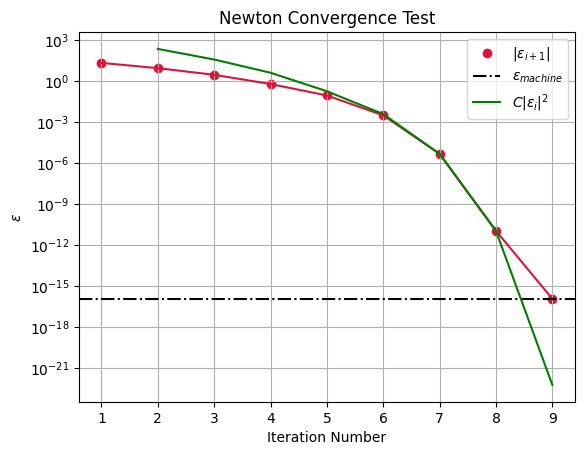

In [15]:
x_true=np.array([2.,1.,2.,2.])       
x_guess=np.array([10.,10.,10.,10.]) 
iterations=100

eps=0.5
while eps+1>1:
    eps=eps/2

err=np.array([])
err=np.append(err,np.sum(np.abs((x_true-x_guess)/x_true)))

x=x_guess
for i in range(iterations):
    delta_x=Gauss_Jordan(Jacobian_test(x),-F_test(x))
    x+=delta_x
    err=np.append(err,np.sum(np.abs((x_true-x)/x_true)))
    if err[i+1]<eps:
        err[i+1]=eps
        num_iterations=i+1
        break

plt.title("Newton Convergence Test")
plt.xlabel("Iteration Number")
plt.ylabel(r'$\epsilon$');

plt.plot((np.arange(0.,num_iterations+1,1.0)+1),err, c='crimson')
plt.scatter((np.arange(0.,num_iterations+1,1.0)+1),err, c='crimson', label=r'$|\epsilon_{i+1}|$')
plt.grid()
C=0.5
#plt.xscale('log')
plt.yscale('log')
plt.axhline(eps, ls='-.',c='k',label=r'$\epsilon_{machine}$')
plt.plot((np.arange(0.,num_iterations+1,1.0)+1)[1:],C*err[0:num_iterations]**2, c='green', label=r'$C |\epsilon_{i}|^2$')
plt.legend(loc='best');

Squared convergence only after iteration 5, plateau at the machine accuracy

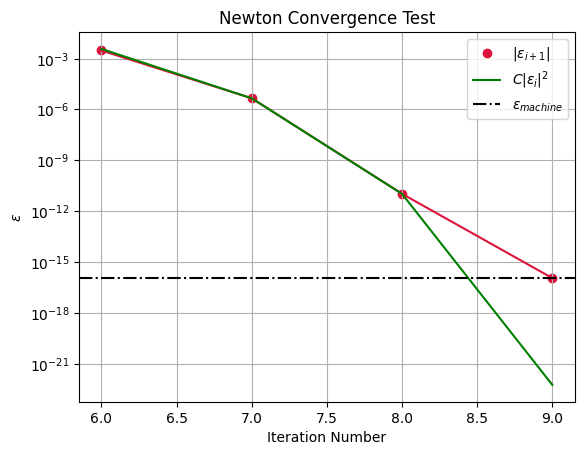

In [16]:
plt.plot((np.arange(0.,num_iterations+1,1.0)+1)[5:],err[5:], c='crimson')
plt.scatter((np.arange(0.,num_iterations+1,1.0)+1)[5:],err[5:], c='crimson', label=r'$|\epsilon_{i+1}|$')
plt.yscale('log')
#plt.xscale('log')
C=0.5
plt.plot((np.arange(0.,num_iterations+1,1.0)+1)[5:],C*err[4:num_iterations]**2, c='green', label=r'$C |\epsilon_{i}|^2$')
plt.axhline(eps, ls='-.',c='k',label=r'$\epsilon_{machine}$')
plt.grid()
plt.legend(loc='best')
plt.title("Newton Convergence Test")
plt.xlabel("Iteration Number")
plt.ylabel(r'$\epsilon$');

# ANALYSIS

Dependencies in a Shakura-Sunyaev $\alpha$ accretion disk:

### Region A (Inner)

- Radiation Pressure + Electron Scattering
- $\Sigma \propto R^{3/2}$
- $T_c \propto R^{-3/8}$
- $T_{max} \propto \dot{M}^{0}$

### Region B (Mid)

- Gas Pressure + Electron Scattering
- $\Sigma \propto R^{-3/5}$
- $T_c \propto R^{-9/10}$
- $T_{max} \propto \dot{M}^{2/5}$

### Region C (Outer)

- Gas Pressure + Kramers' Opacity
- $\Sigma \propto R^{-3/4}$
- $T_c \propto R^{-3/4}$
- $T_{max} \propto \dot{M}^{3/10}$

# $\alpha$=0.001, $\dot{M}$=0.1$\dot{M}_{Edd}$

In [17]:
alpha=0.001 
M=10*Msun
Rstar=6*G*M/c**2
L_Edd=4*np.pi*G*M*mp*c/sigmaT
Mdot_Edd=L_Edd*Rstar/(2*eta*G*M)
Mdot=0.1*Mdot_Edd
Rout=1e8*Rstar
Rvec=np.logspace(np.log10(1.05*Rstar),np.log10(Rout),1000)
Rvec=Rvec[2:]
print("Accretion Rate",Mdot)
print("R Star",Rstar)

Accretion Rate 7.358724597002484e+18
R Star 8893333.333333332


## Initial Guess

My initial is given by solving the simplified equations with neither radiation pressure nor Kramer opacity, which means we're looking at region B, the Mid Disk.

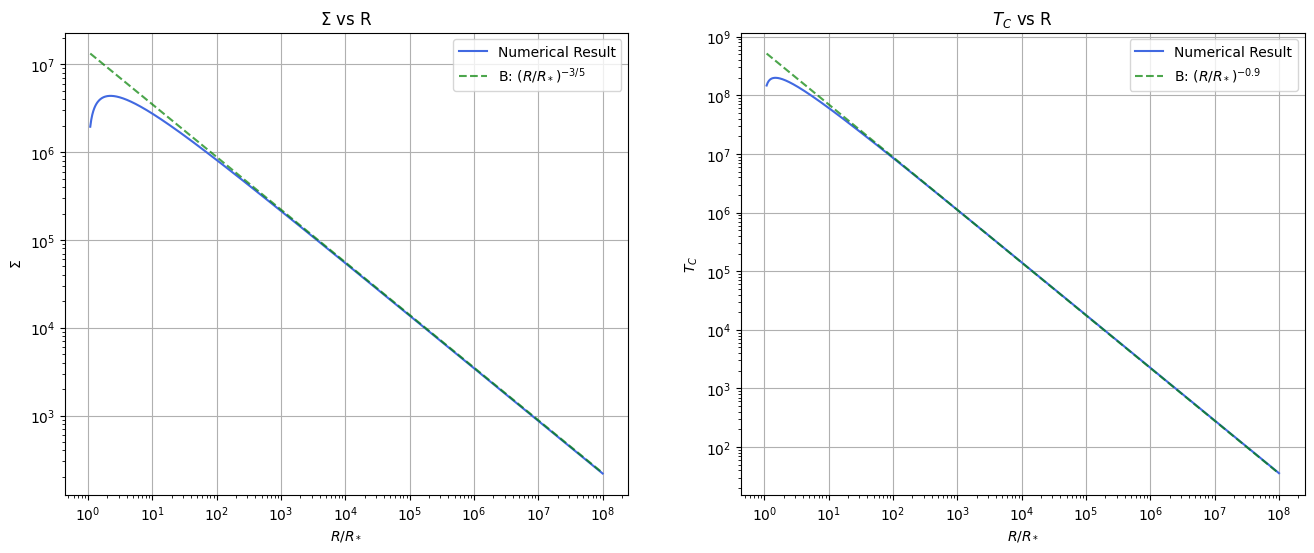

In [18]:
Sigma_vec0=np.array([])
Tc_vec0=np.array([])
H_vec0=np.array([])
rho_c_vec0=np.array([])

for j in range(len(Rvec)):
    R=Rvec[j]
    xk=initial_guess(R,Rstar,M,Mdot, alpha)

    Sigma_vec0=np.append(Sigma_vec0,xk[0])
    Tc_vec0=np.append(Tc_vec0,xk[1])
    H_vec0=np.append(H_vec0,xk[2])
    rho_c_vec0=np.append(rho_c_vec0,xk[3])

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Sigma_vec0, c='royalblue', label='Numerical Result')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/5)*1.4e7, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-3/5}$')

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$\Sigma$")
ax1.grid()
ax1.set_title(r"$\Sigma$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Tc_vec0,label='Numerical Result', c='royalblue')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-0.9)*5.6e8, c='green', ls='--', alpha=0.7, label=r'B: $(R/R_*)^{-0.9}$')

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$T_C$")
ax2.grid()
ax2.set_title(r"$T_C$ vs R")
ax2.legend(loc='best');

## Full Equations

In [19]:
Sigma_vec1=np.array([])
Tc_vec1=np.array([])
H_vec1=np.array([])
rho_c_vec1=np.array([])

for j in range(len(Rvec)):
    R=Rvec[j]

    xk_init=initial_guess(R,Rstar,M,Mdot,alpha)
    yk=np.log(xk_init)

    i=0
    delta_yk=np.zeros(4)+10

    while i<1000:
        xk_current=np.exp(yk)
        residual=np.array(F(xk_current,R,Rstar,M,Mdot,alpha))

        if np.all(np.abs(residual)<1e-10):
            break

        delta_yk=np.array(new_step_log(yk,R,Rstar,M,Mdot,alpha))

        if np.all(np.abs(delta_yk)<1e-12):
            break

        yk=yk+delta_yk
        i+=1

    if i>=1000:
        print("More than a 1000 steps for radius of index",j)
        break

    xk_final=np.exp(yk)
    Sigma_vec1=np.append(Sigma_vec1,xk_final[0])
    Tc_vec1=np.append(Tc_vec1,xk_final[1])
    H_vec1=np.append(H_vec1,xk_final[2])
    rho_c_vec1=np.append(rho_c_vec1,xk_final[3])

### a) Radial profiles

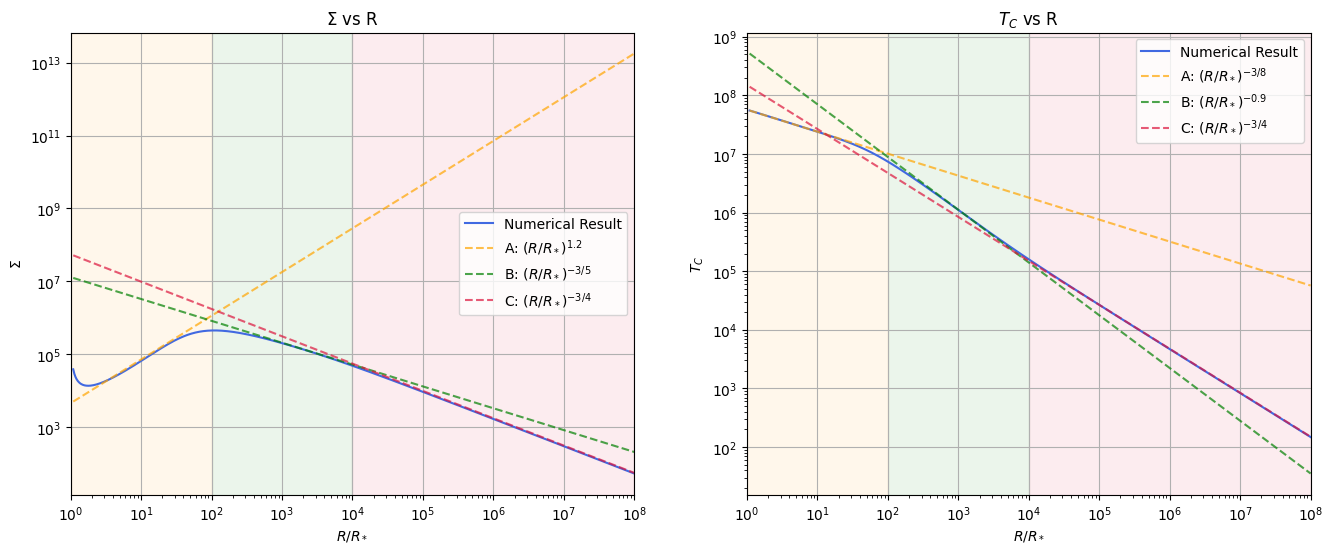

In [20]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Sigma_vec1, label='Numerical Result', c='royalblue')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(1.2)*4.5e3, alpha=0.7, c='orange', ls='--', label=r'A: $(R/R_*)^{1.2}$')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/5)*1.3e7, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-3/5}$')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/4)*5.5e7, alpha=0.7, c='crimson', ls='--', label=r'C: $(R/R_*)^{-3/4}$')

ax1.axvspan(1, 1e2, color='orange', alpha=0.08)
ax1.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax1.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$\Sigma$")
ax1.grid()
ax1.set_title(r"$\Sigma$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Tc_vec1,label='Numerical Result', c='royalblue')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-3/8)*5.7e7, alpha=0.7, c='orange', ls='--', label=r'A: $(R/R_*)^{-3/8}$')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-0.9)*5.6e8, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-0.9}$')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-3/4)*1.5e8, alpha=0.7, c='crimson', ls='--', label=r'C: $(R/R_*)^{-3/4}$')

ax2.axvspan(1, 1e2, color='orange', alpha=0.08)
ax2.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax2.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$T_C$")
ax2.grid()
ax2.set_title(r"$T_C$ vs R")
ax2.legend(loc='best');

We can notice two effects:
1. We have an initial bump in the $\Sigma$, that is commonly referred to as inner viscous torque, this is due to $f(R)$ changing, in a full dynamical simulation we would see a smooth transition with the ISCO;
2. In Region A, $\Sigma$ is growing with $R^{1.2}$ instead of $R^{3/2}$, that is expected at low mass accretion rates and it's explained by considering Region A and B not fully decoupled.

Looking at what's left, the numerical curves follow perfectly what's expected theoretically in the various regions.

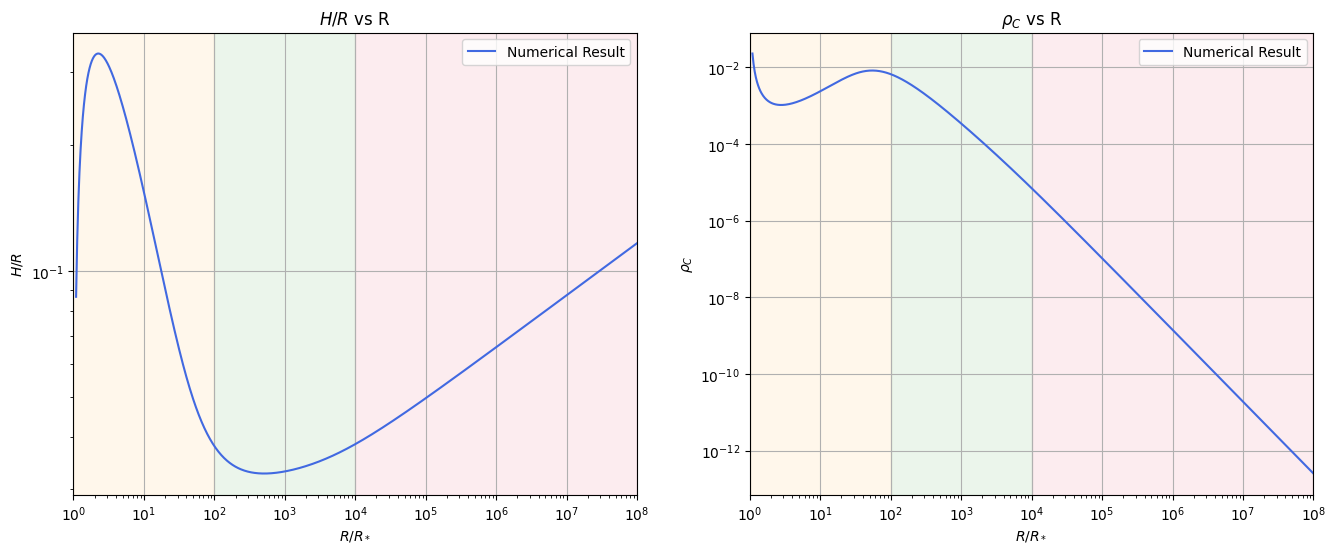

In [21]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,H_vec1/Rvec,label='Numerical Result', c='royalblue')

ax1.axvspan(1, 1e2, color='orange', alpha=0.08)
ax1.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax1.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$H/R$")
ax1.grid()
ax1.set_title(r"$H/R$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,rho_c_vec1,label='Numerical Result', c='royalblue')

ax2.axvspan(1, 1e2, color='orange', alpha=0.08)
ax2.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax2.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$\rho_C$")
ax2.grid()
ax2.set_title(r"$\rho_C$ vs R")
ax2.legend(loc='best');

### b) Pressure regimes and analytical limits

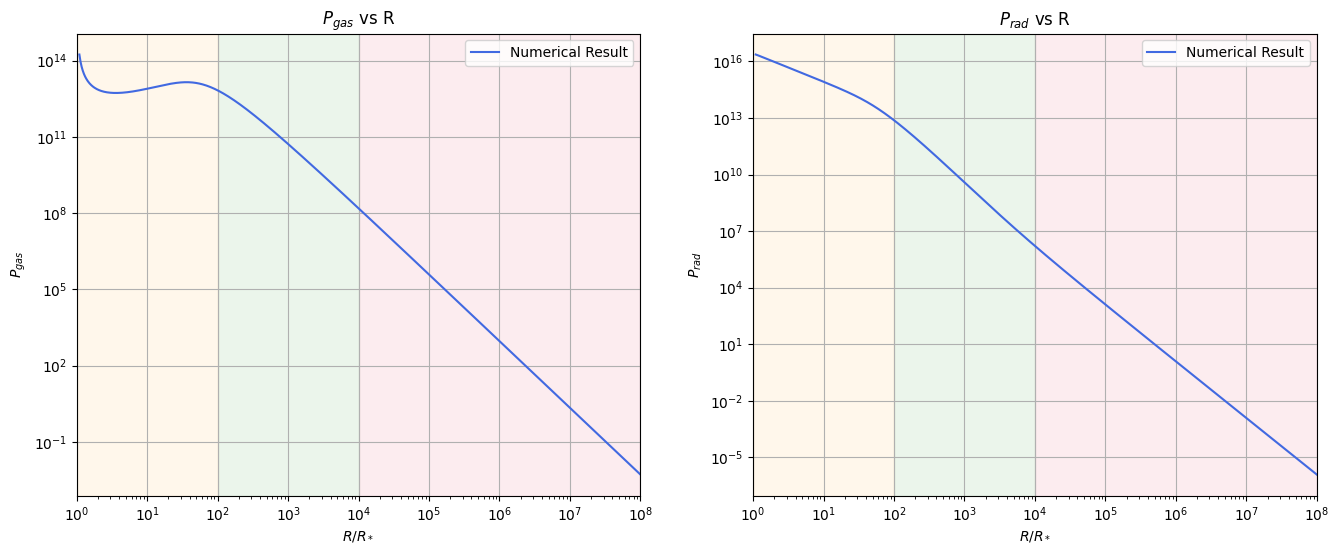

In [22]:
Pgas_vec1,Prad_vec1=P(Tc_vec1,rho_c_vec1)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Pgas_vec1,label='Numerical Result', c='royalblue')

ax1.axvspan(1, 1e2, color='orange', alpha=0.08)
ax1.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax1.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$P_{gas}$")
ax1.grid()
ax1.set_title(r"$P_{gas}$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Prad_vec1,label='Numerical Result', c='royalblue')

ax2.axvspan(1, 1e2, color='orange', alpha=0.08)
ax2.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax2.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$P_{rad}$")
ax2.grid()
ax2.set_title(r"$P_{rad}$ vs R")
ax2.legend(loc='best');

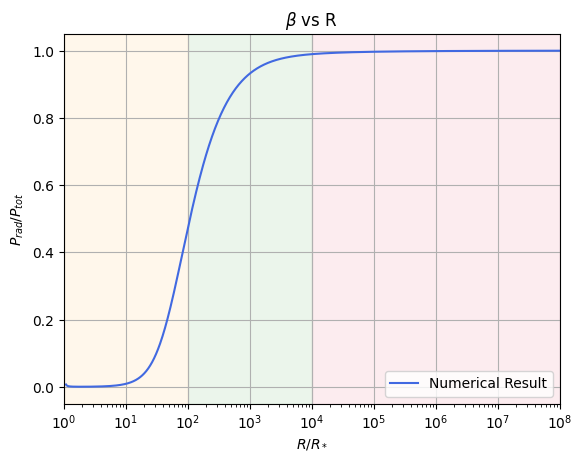

In [23]:
plt.plot((Rvec/Rstar),(Pgas_vec1/(Prad_vec1+Pgas_vec1)),label='Numerical Result', c='royalblue')

plt.axvspan(1, 1e2, color='orange', alpha=0.08)
plt.axvspan(1e2, 1e4, color='green', alpha=0.08)
plt.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

plt.xlim(1,1e8)

plt.xlabel(r"$R/R_*$")
plt.ylabel(r"$P_{rad}/P_{tot}$")
plt.grid()
plt.xscale('log')
plt.title(r"$\beta$ vs R")
plt.legend(loc='best');

# $\alpha$=0.01, $\dot{M}$=0.1$\dot{M}_{Edd}$

In [24]:
alpha=0.01 

Sigma_vec2=np.array([])
Tc_vec2=np.array([])
H_vec2=np.array([])
rho_c_vec2=np.array([])

for j in range(len(Rvec)):
    R=Rvec[j]

    xk_init=initial_guess(R,Rstar,M,Mdot,alpha)
    yk=np.log(xk_init)

    i=0
    delta_yk=np.zeros(4)+10

    while i<1000:
        xk_current=np.exp(yk)
        residual=np.array(F(xk_current,R,Rstar,M,Mdot,alpha))

        if np.all(np.abs(residual)<1e-10):
            break

        delta_yk=np.array(new_step_log(yk,R,Rstar,M,Mdot,alpha))

        if np.all(np.abs(delta_yk)<1e-12):
            break

        yk=yk+delta_yk
        i+=1

    if i>=1000:
        print("More than a 1000 steps for radius of index",j)
        break

    xk_final=np.exp(yk)
    Sigma_vec2=np.append(Sigma_vec2,xk_final[0])
    Tc_vec2=np.append(Tc_vec2,xk_final[1])
    H_vec2=np.append(H_vec2,xk_final[2])
    rho_c_vec2=np.append(rho_c_vec2,xk_final[3])

### a) Radial profiles

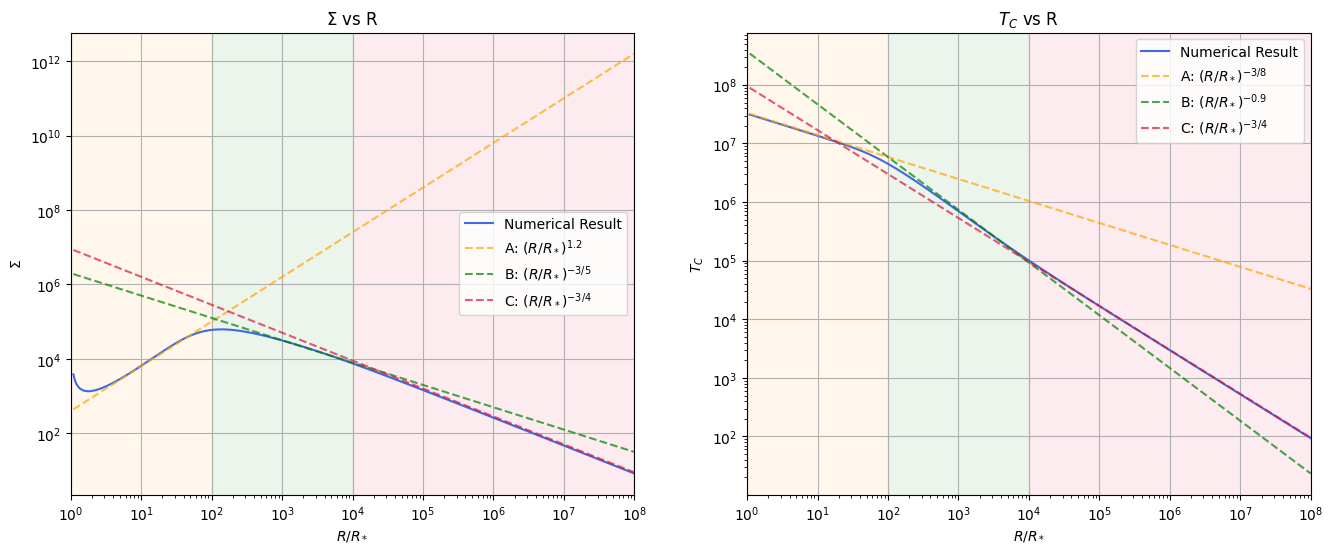

In [25]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Sigma_vec2, label='Numerical Result', c='royalblue')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(1.2)*4e2, alpha=0.7, c='orange', ls='--', label=r'A: $(R/R_*)^{1.2}$')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/5)*2e6, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-3/5}$')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/4)*0.9e7, alpha=0.7, c='crimson', ls='--', label=r'C: $(R/R_*)^{-3/4}$')

ax1.axvspan(1, 1e2, color='orange', alpha=0.08)
ax1.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax1.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$\Sigma$")
ax1.grid()
ax1.set_title(r"$\Sigma$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Tc_vec2,label='Numerical Result', c='royalblue')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-3/8)*3.3e7, alpha=0.7, c='orange', ls='--', label=r'A: $(R/R_*)^{-3/8}$')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-0.9)*3.7e8, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-0.9}$')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-3/4)*9.5e7, alpha=0.7, c='crimson', ls='--', label=r'C: $(R/R_*)^{-3/4}$')

ax2.axvspan(1, 1e2, color='orange', alpha=0.08)
ax2.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax2.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$T_C$")
ax2.grid()
ax2.set_title(r"$T_C$ vs R")
ax2.legend(loc='best');

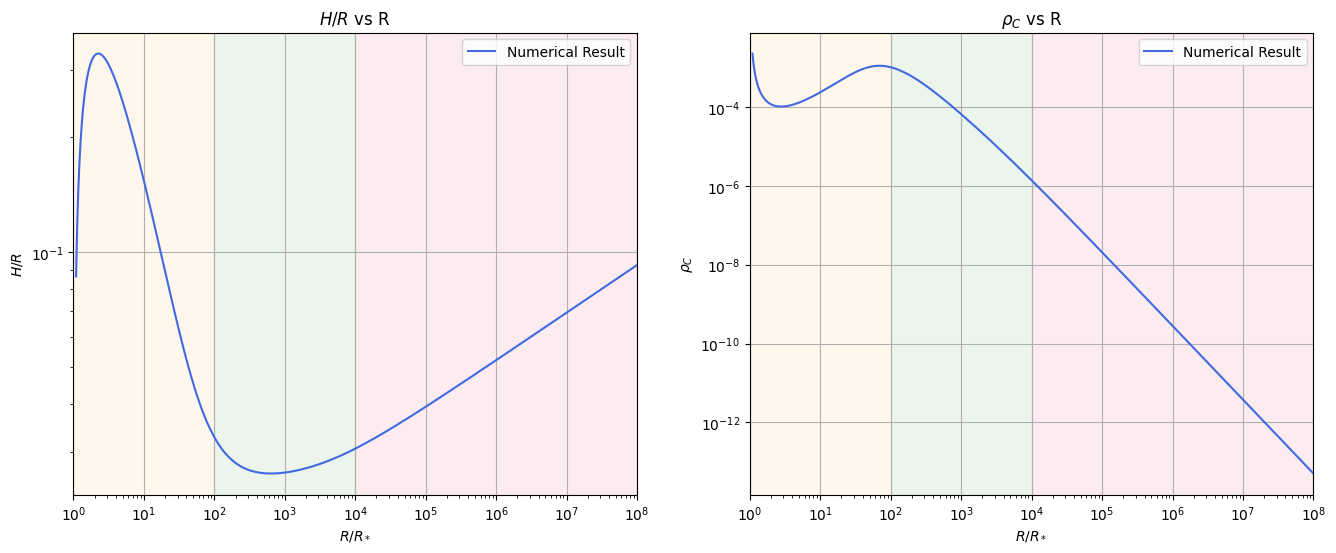

In [26]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,H_vec2/Rvec,label='Numerical Result', c='royalblue')

ax1.axvspan(1, 1e2, color='orange', alpha=0.08)
ax1.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax1.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$H/R$")
ax1.grid()
ax1.set_title(r"$H/R$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,rho_c_vec2,label='Numerical Result', c='royalblue')

ax2.axvspan(1, 1e2, color='orange', alpha=0.08)
ax2.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax2.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$\rho_C$")
ax2.grid()
ax2.set_title(r"$\rho_C$ vs R")
ax2.legend(loc='best');

### b) Pressure regimes and analytical limits

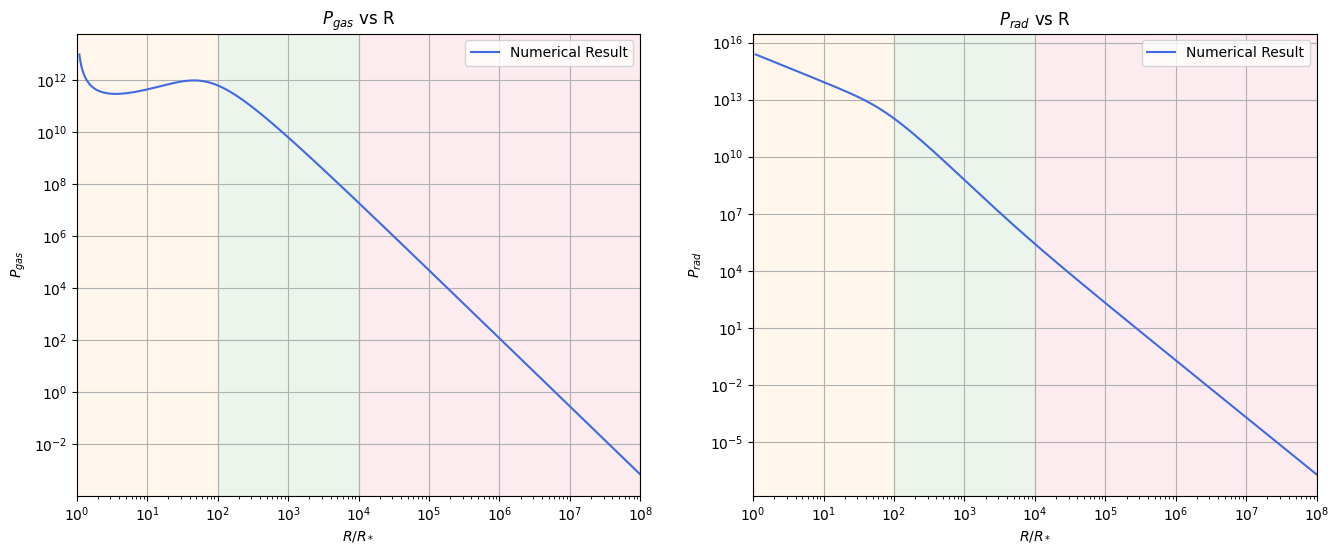

In [27]:
Pgas_vec2,Prad_vec2=P(Tc_vec2,rho_c_vec2)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Pgas_vec2,label='Numerical Result', c='royalblue')

ax1.axvspan(1, 1e2, color='orange', alpha=0.08)
ax1.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax1.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$P_{gas}$")
ax1.grid()
ax1.set_title(r"$P_{gas}$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Prad_vec2,label='Numerical Result', c='royalblue')

ax2.axvspan(1, 1e2, color='orange', alpha=0.08)
ax2.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax2.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$P_{rad}$")
ax2.grid()
ax2.set_title(r"$P_{rad}$ vs R")
ax2.legend(loc='best');

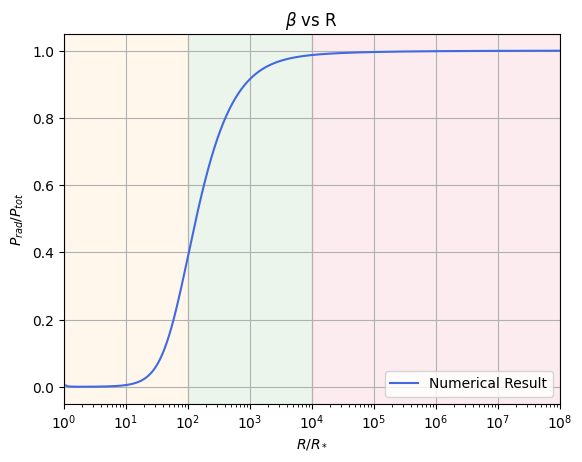

In [28]:
plt.plot((Rvec/Rstar),(Pgas_vec2/(Prad_vec2+Pgas_vec2)),label='Numerical Result', c='royalblue')

plt.axvspan(1, 1e2, color='orange', alpha=0.08)
plt.axvspan(1e2, 1e4, color='green', alpha=0.08)
plt.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

plt.xlim(1,1e8)

plt.xlabel(r"$R/R_*$")
plt.ylabel(r"$P_{rad}/P_{tot}$")
plt.grid()
plt.xscale('log')
plt.title(r"$\beta$ vs R")
plt.legend(loc='best');

# $\alpha$=0.1, $\dot{M}$=0.1$\dot{M}_{Edd}$

In [29]:
alpha=0.1

Sigma_vec3=np.array([])
Tc_vec3=np.array([])
H_vec3=np.array([])
rho_c_vec3=np.array([])

for j in range(len(Rvec)):
    R=Rvec[j]

    xk_init=initial_guess(R,Rstar,M,Mdot,alpha)
    yk=np.log(xk_init)

    i=0
    delta_yk=np.zeros(4)+10

    while i<1000:
        xk_current=np.exp(yk)
        residual=np.array(F(xk_current,R,Rstar,M,Mdot,alpha))

        if np.all(np.abs(residual)<1e-10):
            break

        delta_yk=np.array(new_step_log(yk,R,Rstar,M,Mdot,alpha))

        if np.all(np.abs(delta_yk)<1e-12):
            break

        yk=yk+delta_yk
        i+=1

    if i>=1000:
        print("More than a 1000 steps for radius of index",j)
        break

    xk_final=np.exp(yk)
    Sigma_vec3=np.append(Sigma_vec3,xk_final[0])
    Tc_vec3=np.append(Tc_vec3,xk_final[1])
    H_vec3=np.append(H_vec3,xk_final[2])
    rho_c_vec3=np.append(rho_c_vec3,xk_final[3])

### a) Radial profiles

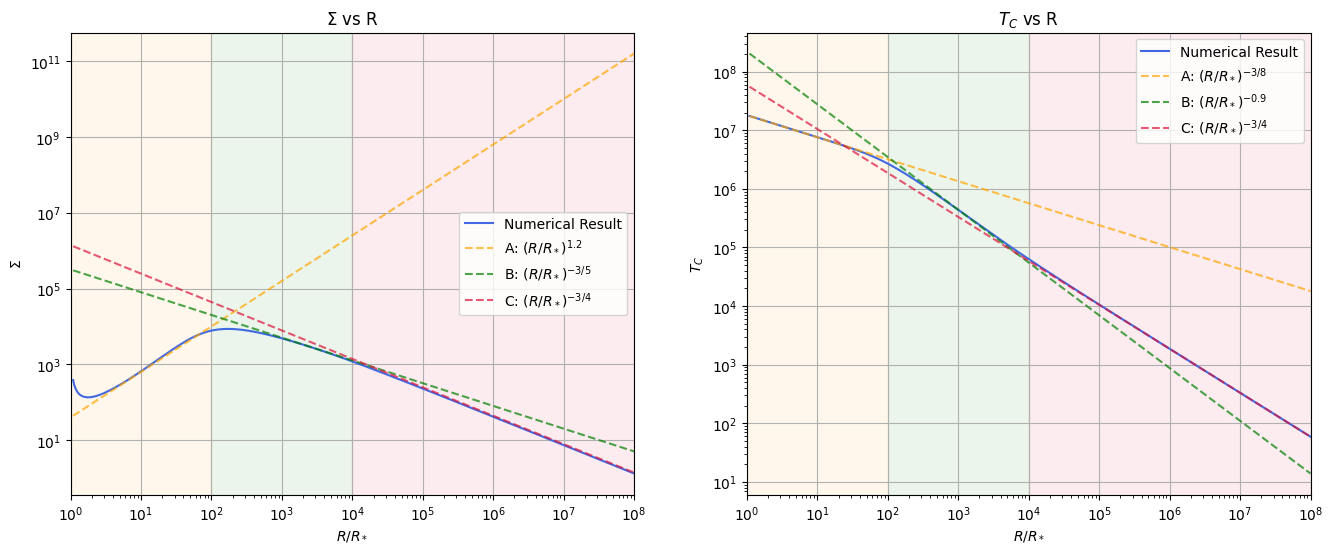

In [30]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Sigma_vec3, label='Numerical Result', c='royalblue')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(1.2)*4e1, alpha=0.7, c='orange', ls='--', label=r'A: $(R/R_*)^{1.2}$')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/5)*3.2e5, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-3/5}$')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/4)*1.4e6, alpha=0.7, c='crimson', ls='--', label=r'C: $(R/R_*)^{-3/4}$')

ax1.axvspan(1, 1e2, color='orange', alpha=0.08)
ax1.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax1.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$\Sigma$")
ax1.grid()
ax1.set_title(r"$\Sigma$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Tc_vec3,label='Numerical Result', c='royalblue')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-3/8)*1.8e7, alpha=0.7, c='orange', ls='--', label=r'A: $(R/R_*)^{-3/8}$')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-0.9)*2.2e8, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-0.9}$')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-3/4)*5.9e7, alpha=0.7, c='crimson', ls='--', label=r'C: $(R/R_*)^{-3/4}$')

ax2.axvspan(1, 1e2, color='orange', alpha=0.08)
ax2.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax2.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$T_C$")
ax2.grid()
ax2.set_title(r"$T_C$ vs R")
ax2.legend(loc='best');

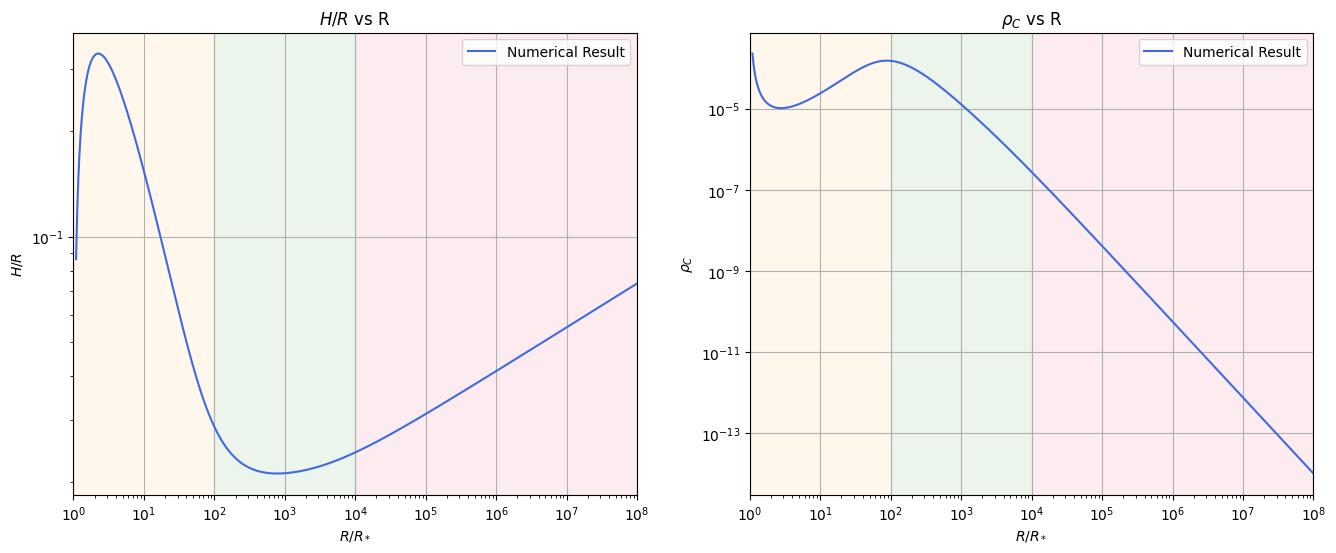

In [31]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,H_vec3/Rvec,label='Numerical Result', c='royalblue')

ax1.axvspan(1, 1e2, color='orange', alpha=0.08)
ax1.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax1.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$H/R$")
ax1.grid()
ax1.set_title(r"$H/R$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,rho_c_vec3,label='Numerical Result', c='royalblue')

ax2.axvspan(1, 1e2, color='orange', alpha=0.08)
ax2.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax2.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$\rho_C$")
ax2.grid()
ax2.set_title(r"$\rho_C$ vs R")
ax2.legend(loc='best');

### b) Pressure regimes and analytical limits

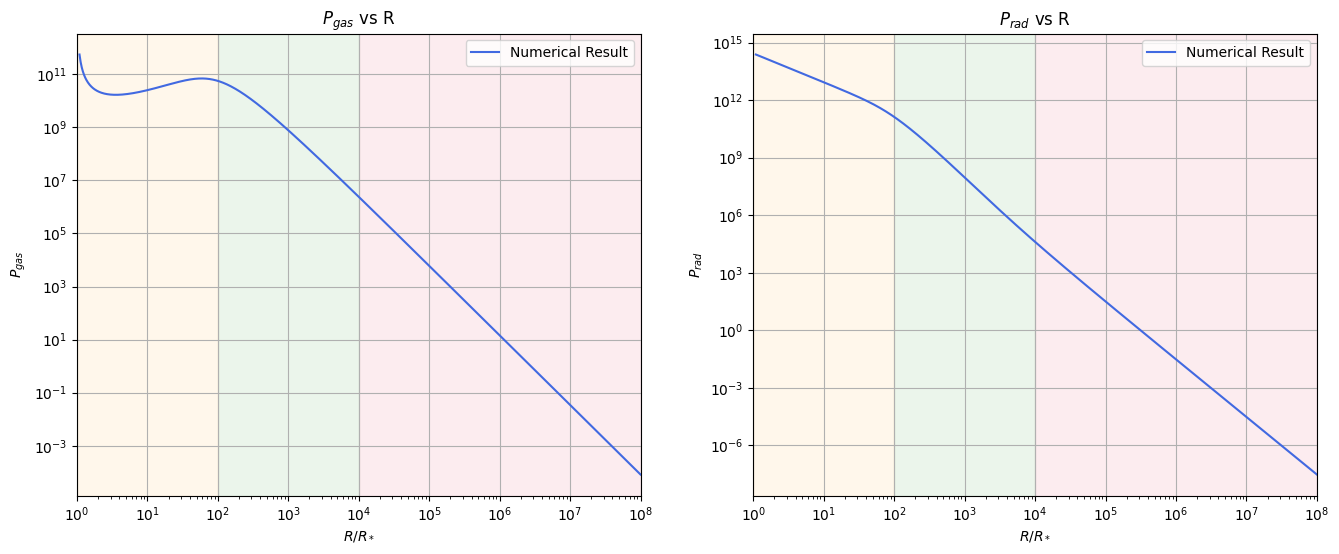

In [32]:
Pgas_vec3,Prad_vec3=P(Tc_vec3,rho_c_vec3)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Pgas_vec3,label='Numerical Result', c='royalblue')

ax1.axvspan(1, 1e2, color='orange', alpha=0.08)
ax1.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax1.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$P_{gas}$")
ax1.grid()
ax1.set_title(r"$P_{gas}$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Prad_vec3,label='Numerical Result', c='royalblue')

ax2.axvspan(1, 1e2, color='orange', alpha=0.08)
ax2.axvspan(1e2, 1e4, color='green', alpha=0.08)
ax2.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$P_{rad}$")
ax2.grid()
ax2.set_title(r"$P_{rad}$ vs R")
ax2.legend(loc='best');

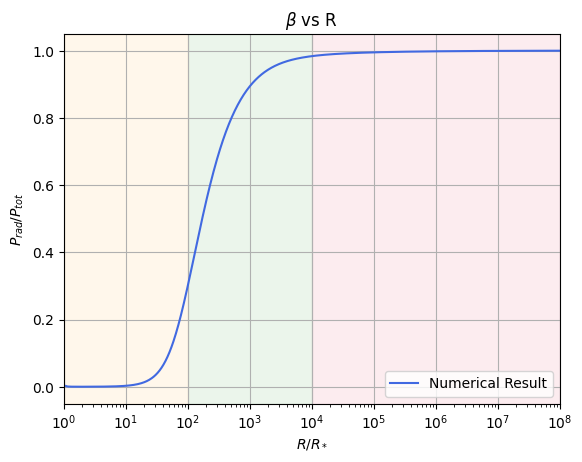

In [33]:
plt.plot((Rvec/Rstar),(Pgas_vec3/(Prad_vec3+Pgas_vec3)),label='Numerical Result', c='royalblue')

plt.axvspan(1, 1e2, color='orange', alpha=0.08)
plt.axvspan(1e2, 1e4, color='green', alpha=0.08)
plt.axvspan(1e4, 1e8, color='crimson', alpha=0.08)

plt.xlim(1,1e8)

plt.xlabel(r"$R/R_*$")
plt.ylabel(r"$P_{rad}/P_{tot}$")
plt.grid()
plt.xscale('log')
plt.title(r"$\beta$ vs R")
plt.legend(loc='best');

# $\alpha=0.1$, $\dot{M}=\dot{M}_{Edd}$

In [34]:
alpha=0.1
Mdot=Mdot_Edd

Sigma_vec5=np.array([])
Tc_vec5=np.array([])
H_vec5=np.array([])
rho_c_vec5=np.array([])

for j in range(len(Rvec)):
    R=Rvec[j]

    xk_init=initial_guess(R,Rstar,M,Mdot,alpha)
    yk=np.log(xk_init)

    i=0
    delta_yk=np.zeros(4)+10

    while i<1000:
        xk_current=np.exp(yk)
        residual=np.array(F(xk_current,R,Rstar,M,Mdot,alpha))

        if np.all(np.abs(residual)<1e-10):
            break

        delta_yk=np.array(new_step_log(yk,R,Rstar,M,Mdot,alpha))

        if np.all(np.abs(delta_yk)<1e-12):
            break

        yk=yk+delta_yk
        i+=1

    if i>=1000:
        print("More than a 1000 steps for radius of index",j)
        break

    xk_final=np.exp(yk)
    Sigma_vec5=np.append(Sigma_vec5,xk_final[0])
    Tc_vec5=np.append(Tc_vec5,xk_final[1])
    H_vec5=np.append(H_vec5,xk_final[2])
    rho_c_vec5=np.append(rho_c_vec5,xk_final[3])

### a) Radial profiles

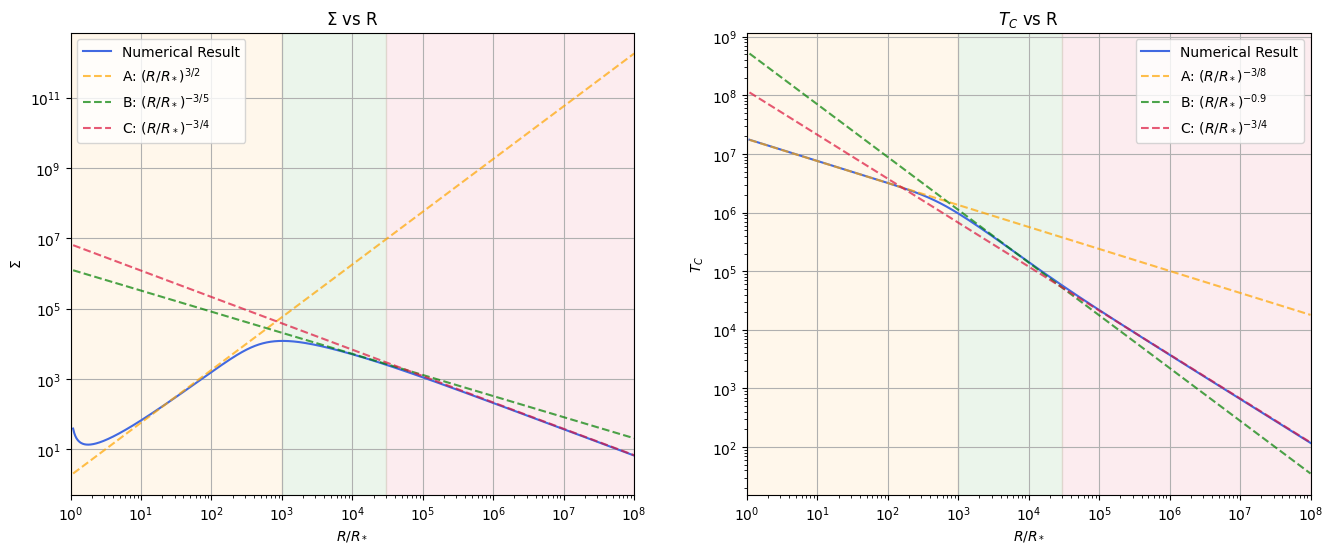

In [35]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Sigma_vec5, label='Numerical Result', c='royalblue')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(3/2)*1.8e0, alpha=0.7, c='orange', ls='--', label=r'A: $(R/R_*)^{3/2}$')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/5)*1.3e6, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-3/5}$')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/4)*6.8e6, alpha=0.7, c='crimson', ls='--', label=r'C: $(R/R_*)^{-3/4}$')

ax1.axvspan(1, 1e3, color='orange', alpha=0.08)
ax1.axvspan(1e3, 3e4, color='green', alpha=0.08)
ax1.axvspan(3e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$\Sigma$")
ax1.grid()
ax1.set_title(r"$\Sigma$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Tc_vec5,label='Numerical Result', c='royalblue')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-3/8)*1.8e7, alpha=0.7, c='orange', ls='--', label=r'A: $(R/R_*)^{-3/8}$')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-0.9)*5.6e8, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-0.9}$')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-3/4)*1.2e8, alpha=0.7, c='crimson', ls='--', label=r'C: $(R/R_*)^{-3/4}$')

ax2.axvspan(1, 1e3, color='orange', alpha=0.08)
ax2.axvspan(1e3, 3e4, color='green', alpha=0.08)
ax2.axvspan(3e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$T_C$")
ax2.grid()
ax2.set_title(r"$T_C$ vs R")
ax2.legend(loc='best');

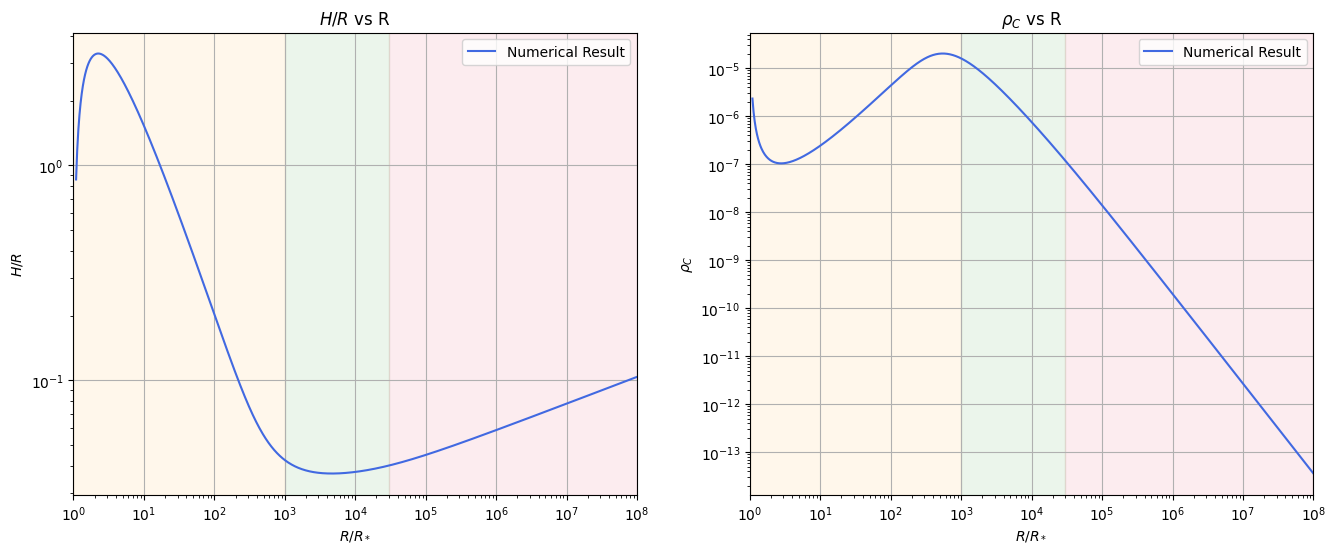

In [36]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,H_vec5/Rvec,label='Numerical Result', c='royalblue')

ax1.axvspan(1, 1e3, color='orange', alpha=0.08)
ax1.axvspan(1e3, 3e4, color='green', alpha=0.08)
ax1.axvspan(3e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$H/R$")
ax1.grid()
ax1.set_title(r"$H/R$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,rho_c_vec5,label='Numerical Result', c='royalblue')

ax2.axvspan(1, 1e3, color='orange', alpha=0.08)
ax2.axvspan(1e3, 3e4, color='green', alpha=0.08)
ax2.axvspan(3e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$\rho_C$")
ax2.grid()
ax2.set_title(r"$\rho_C$ vs R")
ax2.legend(loc='best');

### b) Pressure regimes and analytical limits

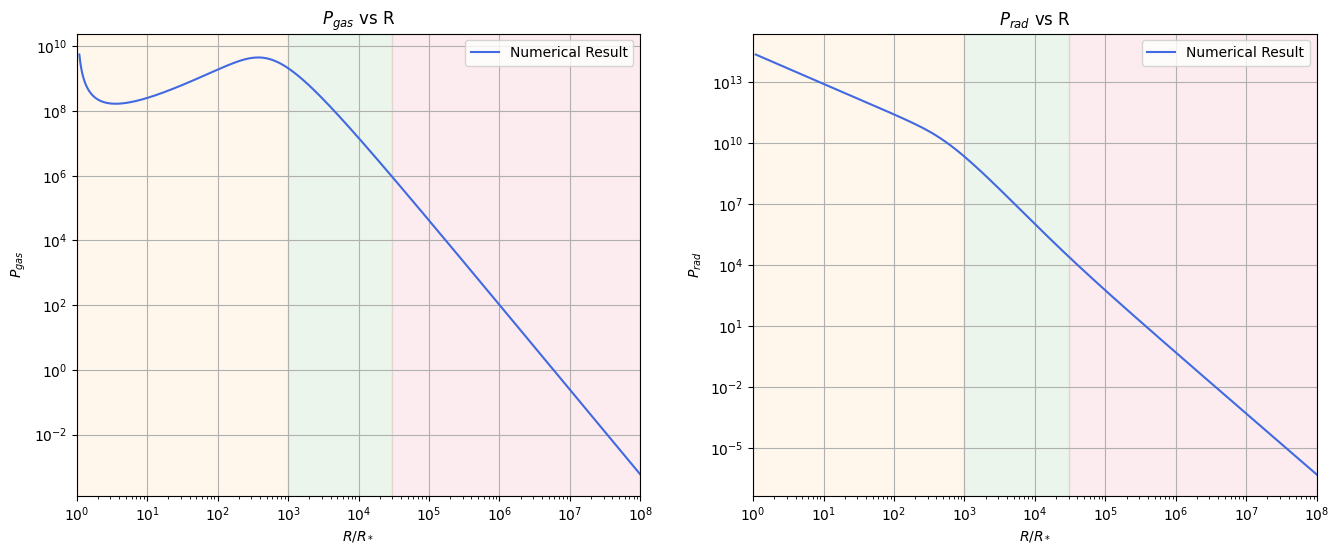

In [37]:
Pgas_vec5,Prad_vec5=P(Tc_vec5,rho_c_vec5)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Pgas_vec5,label='Numerical Result', c='royalblue')

ax1.axvspan(1, 1e3, color='orange', alpha=0.08)
ax1.axvspan(1e3, 3e4, color='green', alpha=0.08)
ax1.axvspan(3e4, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$P_{gas}$")
ax1.grid()
ax1.set_title(r"$P_{gas}$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Prad_vec5,label='Numerical Result', c='royalblue')

ax2.axvspan(1, 1e3, color='orange', alpha=0.08)
ax2.axvspan(1e3, 3e4, color='green', alpha=0.08)
ax2.axvspan(3e4, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$P_{rad}$")
ax2.grid()
ax2.set_title(r"$P_{rad}$ vs R")
ax2.legend(loc='best');

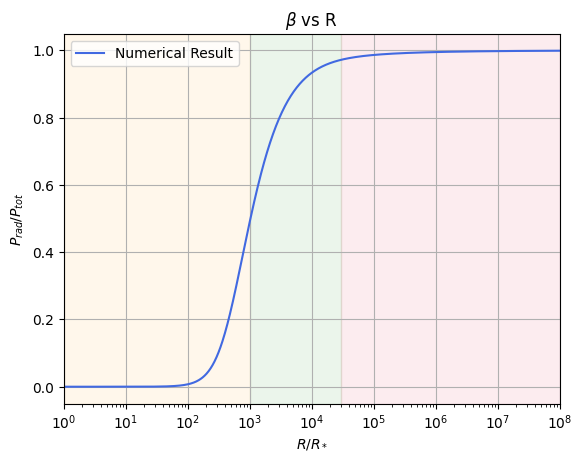

In [38]:
plt.plot((Rvec/Rstar),(Pgas_vec5/(Prad_vec5+Pgas_vec5)),label='Numerical Result', c='royalblue')

plt.axvspan(1, 1e3, color='orange', alpha=0.08)
plt.axvspan(1e3, 3e4, color='green', alpha=0.08)
plt.axvspan(3e4, 1e8, color='crimson', alpha=0.08)

plt.xlim(1,1e8)

plt.xlabel(r"$R/R_*$")
plt.ylabel(r"$P_{rad}/P_{tot}$")
plt.grid()
plt.xscale('log')
plt.title(r"$\beta$ vs R")
plt.legend(loc='best');

### $\alpha=0.1$, $\dot{M}=10^2\dot{M}_{Edd}$

In [39]:
alpha=0.1
Mdot=1e2*Mdot_Edd

Sigma_vec4=np.array([])
Tc_vec4=np.array([])
H_vec4=np.array([])
rho_c_vec4=np.array([])

for j in range(len(Rvec)):
    R=Rvec[j]

    xk_init=initial_guess(R,Rstar,M,Mdot,alpha)
    yk=np.log(xk_init)

    i=0
    delta_yk=np.zeros(4)+10

    while i<1000:
        xk_current=np.exp(yk)
        residual=np.array(F(xk_current,R,Rstar,M,Mdot,alpha))

        if np.all(np.abs(residual)<1e-10):
            break

        delta_yk=np.array(new_step_log(yk,R,Rstar,M,Mdot,alpha))

        if np.all(np.abs(delta_yk)<1e-12):
            break

        yk=yk+delta_yk
        i+=1

    if i>=1000:
        print("More than a 1000 steps for radius of index",j)
        break

    xk_final=np.exp(yk)
    Sigma_vec4=np.append(Sigma_vec4,xk_final[0])
    Tc_vec4=np.append(Tc_vec4,xk_final[1])
    H_vec4=np.append(H_vec4,xk_final[2])
    rho_c_vec4=np.append(rho_c_vec4,xk_final[3])

### a) Radial profiles

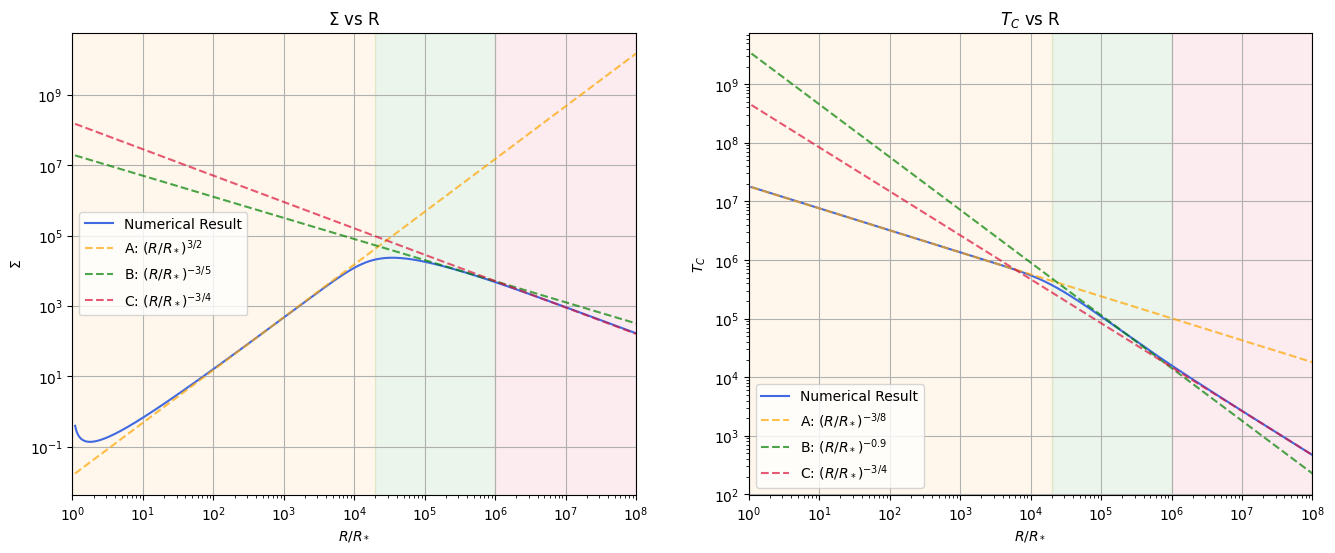

In [40]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Sigma_vec4, label='Numerical Result', c='royalblue')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(3/2)*1.5e-2, alpha=0.7, c='orange', ls='--', label=r'A: $(R/R_*)^{3/2}$')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/5)*2e7, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-3/5}$')
ax1.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/4)*1.6e8, alpha=0.7, c='crimson', ls='--', label=r'C: $(R/R_*)^{-3/4}$')

ax1.axvspan(1, 2e4, color='orange', alpha=0.08)
ax1.axvspan(2e4, 1e6, color='green', alpha=0.08)
ax1.axvspan(1e6, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$\Sigma$")
ax1.grid()
ax1.set_title(r"$\Sigma$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Tc_vec4,label='Numerical Result', c='royalblue')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-3/8)*1.8e7, alpha=0.7, c='orange', ls='--', label=r'A: $(R/R_*)^{-3/8}$')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-0.9)*3.6e9, alpha=0.7, c='green', ls='--', label=r'B: $(R/R_*)^{-0.9}$')
ax2.plot((Rvec/Rstar),(Rvec/Rstar)**(-3/4)*4.7e8, alpha=0.7, c='crimson', ls='--', label=r'C: $(R/R_*)^{-3/4}$')

ax2.axvspan(1, 2e4, color='orange', alpha=0.08)
ax2.axvspan(2e4, 1e6, color='green', alpha=0.08)
ax2.axvspan(1e6, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$T_C$")
ax2.grid()
ax2.set_title(r"$T_C$ vs R")
ax2.legend(loc='best');

With a larger mass accretion rate, we observe Region A in full effect with a slope of $R^{3/2}$

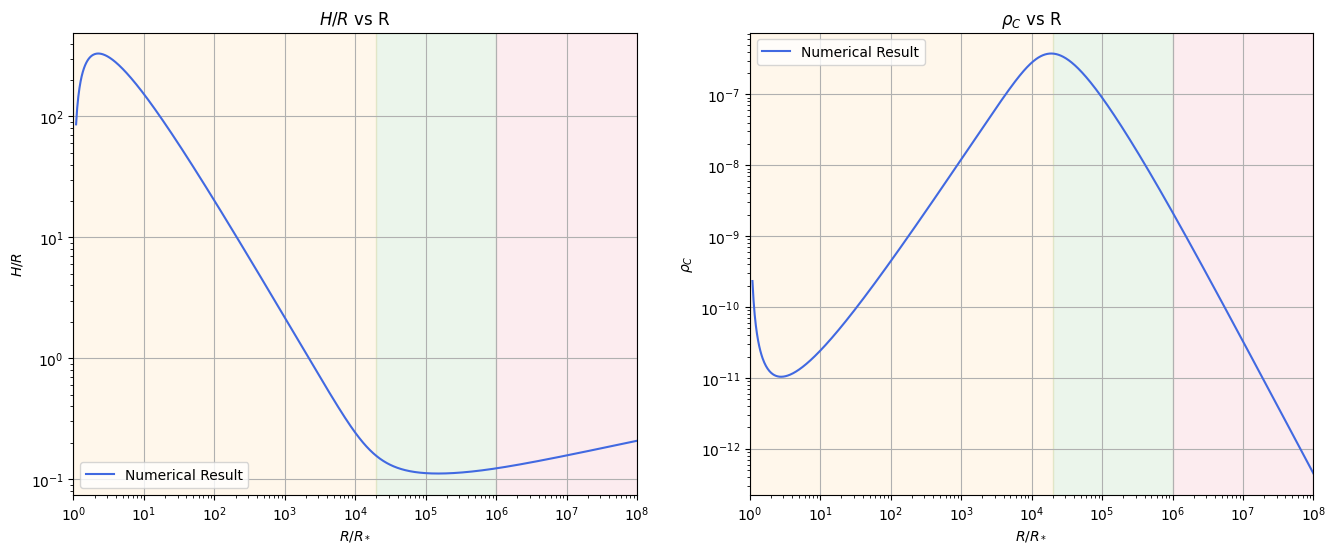

In [41]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,H_vec4/Rvec,label='Numerical Result', c='royalblue')

ax1.axvspan(1, 2e4, color='orange', alpha=0.08)
ax1.axvspan(2e4, 1e6, color='green', alpha=0.08)
ax1.axvspan(1e6, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$H/R$")
ax1.grid()
ax1.set_title(r"$H/R$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,rho_c_vec4,label='Numerical Result', c='royalblue')

ax2.axvspan(1, 2e4, color='orange', alpha=0.08)
ax2.axvspan(2e4, 1e6, color='green', alpha=0.08)
ax2.axvspan(1e6, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$\rho_C$")
ax2.grid()
ax2.set_title(r"$\rho_C$ vs R")
ax2.legend(loc='best');

### b) Pressure regimes and analytical limits

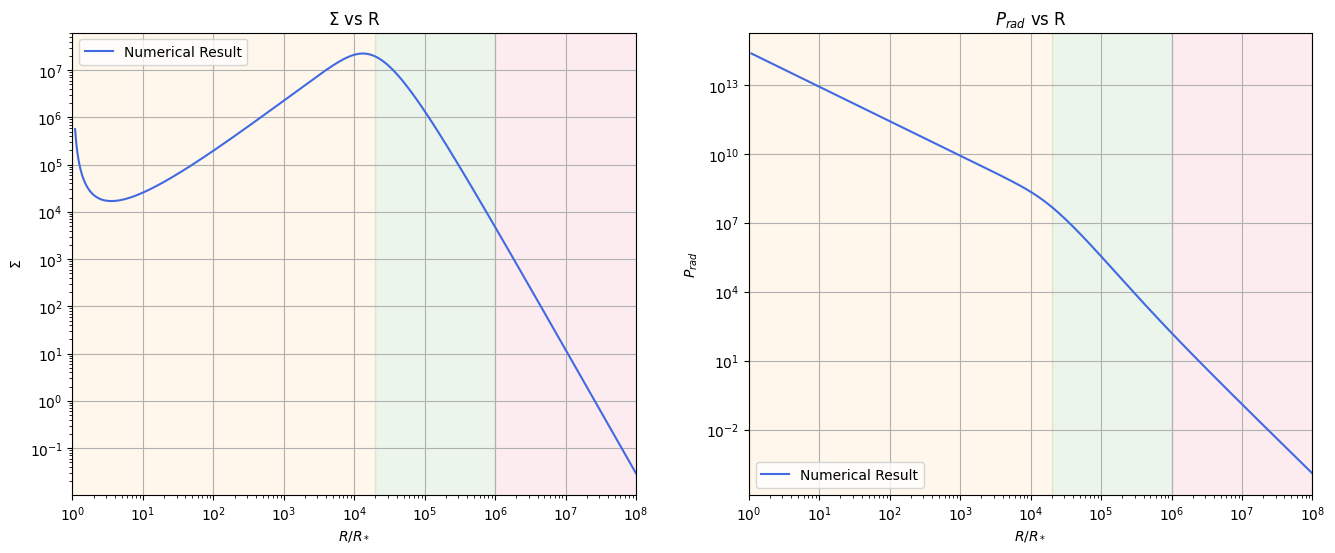

In [42]:
Pgas_vec4,Prad_vec4=P(Tc_vec4,rho_c_vec4)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Pgas_vec4,label='Numerical Result', c='royalblue')

ax1.axvspan(1, 2e4, color='orange', alpha=0.08)
ax1.axvspan(2e4, 1e6, color='green', alpha=0.08)
ax1.axvspan(1e6, 1e8, color='crimson', alpha=0.08)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$\Sigma$")
ax1.grid()
ax1.set_title(r"$\Sigma$ vs R")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Prad_vec4,label='Numerical Result', c='royalblue')

ax2.axvspan(1, 2e4, color='orange', alpha=0.08)
ax2.axvspan(2e4, 1e6, color='green', alpha=0.08)
ax2.axvspan(1e6, 1e8, color='crimson', alpha=0.08)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$P_{rad}$")
ax2.grid()
ax2.set_title(r"$P_{rad}$ vs R")
ax2.legend(loc='best');

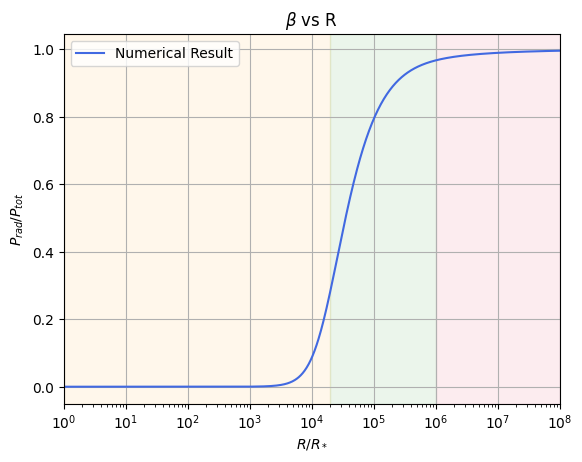

In [43]:
plt.plot((Rvec/Rstar),(Pgas_vec4/(Prad_vec4+Pgas_vec4)),label='Numerical Result', c='royalblue')

plt.axvspan(1, 2e4, color='orange', alpha=0.08)
plt.axvspan(2e4, 1e6, color='green', alpha=0.08)
plt.axvspan(1e6, 1e8, color='crimson', alpha=0.08)

plt.xlim(1,1e8)

plt.xlabel(r"$R/R_*$")
plt.ylabel(r"$P_{rad}/P_{tot}$")
plt.grid()
plt.xscale('log')
plt.title(r"$\beta$ vs R")
plt.legend(loc='best');

### $\alpha$ and $\dot{M}$ Comparison

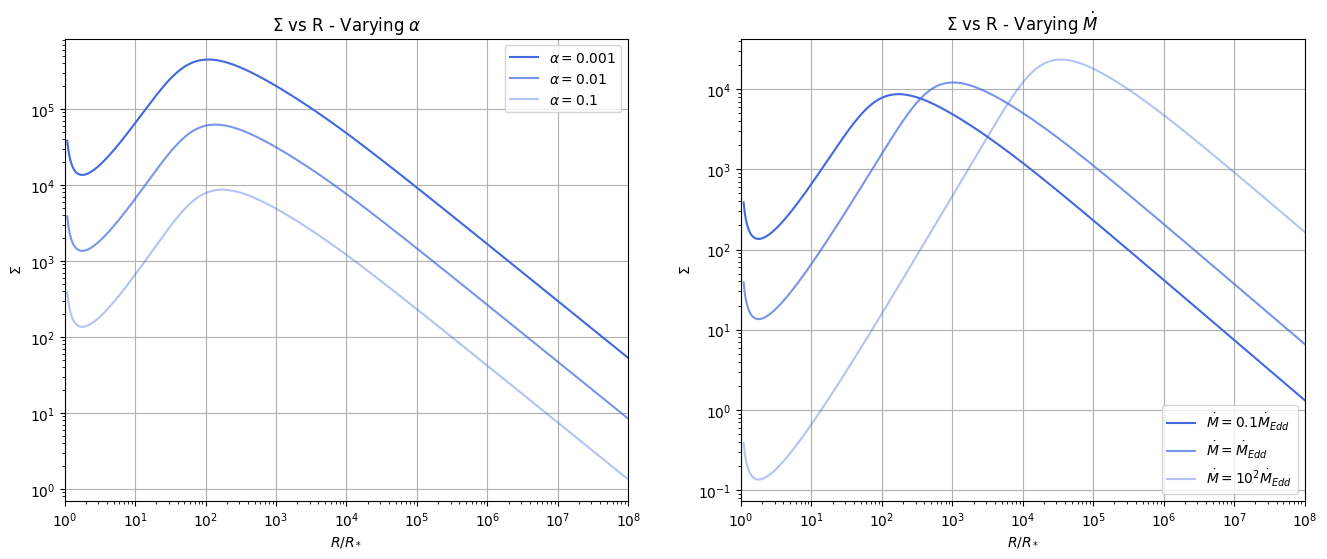

In [44]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Sigma_vec1, label=r'$\alpha=0.001$', c='royalblue')
ax1.plot(Rvec/Rstar,Sigma_vec2, label=r'$\alpha=0.01$', c='royalblue', alpha=0.7)
ax1.plot(Rvec/Rstar,Sigma_vec3, label=r'$\alpha=0.1$', c='royalblue', alpha=0.4)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$\Sigma$")
ax1.grid()
ax1.set_title(r"$\Sigma$ vs R - Varying $\alpha$")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Sigma_vec3, label=r'$\dot{M}=0.1 \dot{M}_{Edd}$', c='royalblue')
ax2.plot(Rvec/Rstar,Sigma_vec5, label=r'$\dot{M}=\dot{M}_{Edd}$', c='royalblue', alpha=0.7)
ax2.plot(Rvec/Rstar,Sigma_vec4, label=r'$\dot{M}=10^2 \dot{M}_{Edd}$', c='royalblue', alpha=0.4)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$\Sigma$")
ax2.grid()
ax2.set_title(r"$\Sigma$ vs R - Varying $\dot{M}$")
ax2.legend(loc='best');

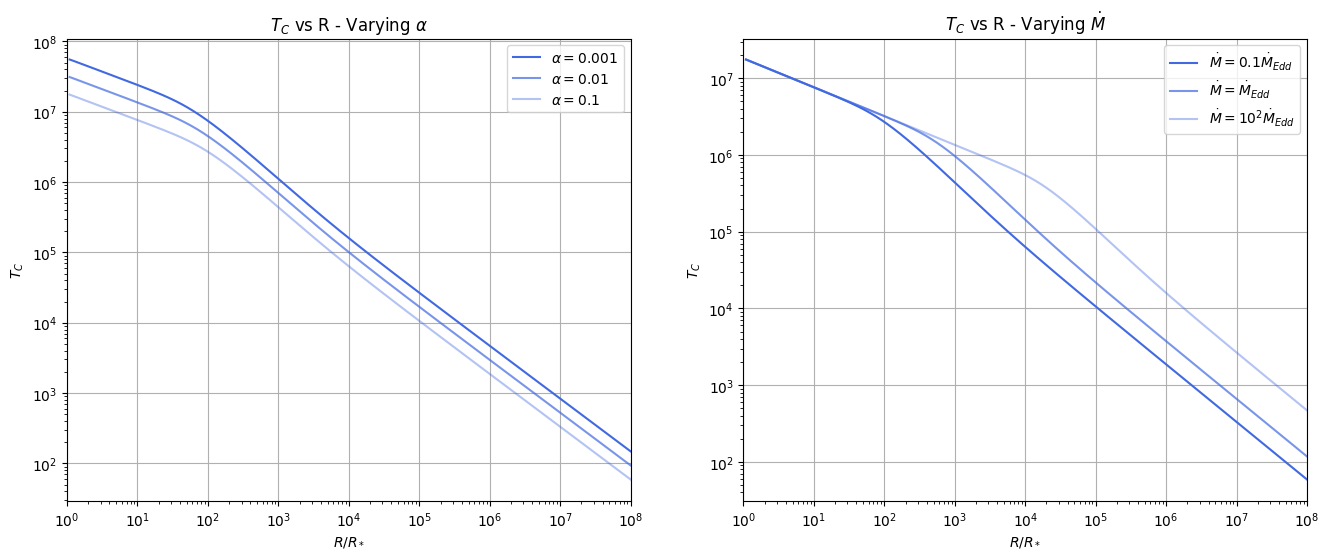

In [45]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Rvec/Rstar,Tc_vec1, label=r'$\alpha=0.001$', c='royalblue')
ax1.plot(Rvec/Rstar,Tc_vec2, label=r'$\alpha=0.01$', c='royalblue', alpha=0.7)
ax1.plot(Rvec/Rstar,Tc_vec3, label=r'$\alpha=0.1$', c='royalblue', alpha=0.4)

ax1.set_xlim(1,1e8)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$R/R_*$")
ax1.set_ylabel(r"$T_C$")
ax1.grid()
ax1.set_title(r"$T_C$ vs R - Varying $\alpha$")
ax1.legend(loc='best');

ax2.plot(Rvec/Rstar,Tc_vec3, label=r'$\dot{M}=0.1 \dot{M}_{Edd}$', c='royalblue')
ax2.plot(Rvec/Rstar,Tc_vec5, label=r'$\dot{M}=\dot{M}_{Edd}$', c='royalblue', alpha=0.7)
ax2.plot(Rvec/Rstar,Tc_vec4, label=r'$\dot{M}=10^2 \dot{M}_{Edd}$', c='royalblue', alpha=0.4)

ax2.set_xlim(1,1e8)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$R/R_*$")
ax2.set_ylabel(r"$T_C$")
ax2.grid()
ax2.set_title(r"$T_C$ vs R - Varying $\dot{M}$")
ax2.legend(loc='best');

### c) Peak temperature scaling

### $\alpha$=0.1

In [46]:
alpha=0.1
N=50

M_dot_vec=np.logspace(np.log10(1e-9*Mdot_Edd),np.log10(1e2*Mdot_Edd),N)

Tmax_vec=np.zeros(N)

for l in range(len(M_dot_vec)):
    Mdot=M_dot_vec[l]
    
    Sigma_vec=np.array([])
    Tc_vec=np.array([])
    H_vec=np.array([])
    rho_c_vec=np.array([])
    
    for j in range(len(Rvec)):
        R=Rvec[j]
    
        xk_init=initial_guess(R,Rstar,M,Mdot,alpha)
        yk=np.log(xk_init)
    
        i=0
        delta_yk=np.zeros(4)+10
    
        while i<1000:
            xk_current=np.exp(yk)
            residual=np.array(F(xk_current,R,Rstar,M,Mdot,alpha))
    
            if np.all(np.abs(residual)<1e-10):
                break
    
            delta_yk=np.array(new_step_log(yk,R,Rstar,M,Mdot,alpha))
    
            if np.all(np.abs(delta_yk)<1e-12):
                break
    
            yk=yk+delta_yk
            i+=1
    
        if i>=1000:
            print("More than a 1000 steps for radius of index",j)
            break
    
        xk_final=np.exp(yk)
        Sigma_vec=np.append(Sigma_vec,xk_final[0])
        Tc_vec=np.append(Tc_vec,xk_final[1])
        H_vec=np.append(H_vec,xk_final[2])
        rho_c_vec=np.append(rho_c_vec,xk_final[3])

    Tmax_vec[l] = np.max(Tc_vec)

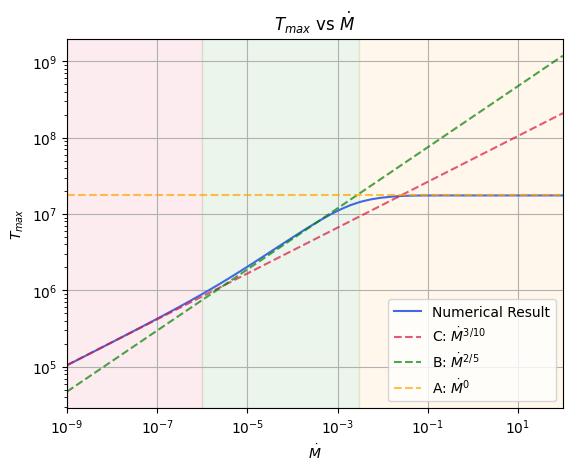

In [47]:
plt.plot(M_dot_vec/Mdot_Edd,Tmax_vec,label='Numerical Result',c='royalblue')
plt.plot(M_dot_vec/Mdot_Edd,(M_dot_vec/Mdot_Edd)**(3/10)*M**(1/4)*1.4e-1, alpha=0.7, c='crimson', ls='--', label=r'C: $\dot{M}^{3/10}$')
plt.plot(M_dot_vec/Mdot_Edd,(M_dot_vec/Mdot_Edd)**(2/5)*M**(1/4)*5e-1, alpha=0.7, c='green', ls='--', label=r'B: $\dot{M}^{2/5}$')
plt.plot(M_dot_vec/Mdot_Edd,[1.8e7]*len(M_dot_vec), alpha=0.7, c='orange', ls='--', label=r'A: $\dot{M}^{0}$')

plt.axvspan(3e-3, 1e2, color='orange', alpha=0.08)
plt.axvspan(1e-6, 3e-3, color='green', alpha=0.08)
plt.axvspan(1e-9, 1e-6, color='crimson', alpha=0.08)

plt.xlim(1e-9,1e2)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\dot{M}$")
plt.ylabel(r"$T_{max}$")
plt.grid()
plt.title(r"$T_{max}$ vs $\dot{M}$")
plt.legend(loc='best');

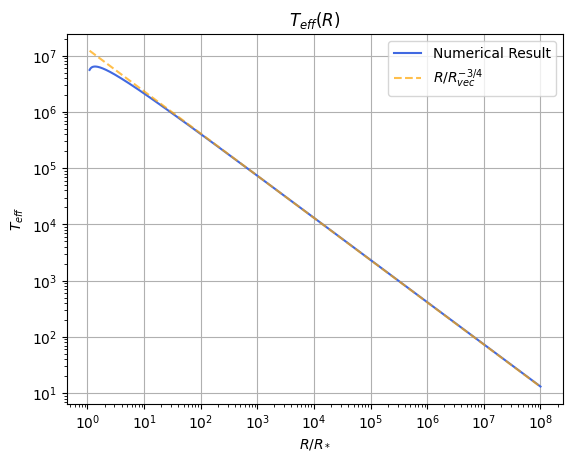

In [48]:
Mdot=0.1*Mdot_Edd
plt.plot(Rvec/Rstar,Teff(Rvec,Rstar,M,Mdot), c='royalblue', label='Numerical Result')
plt.plot(Rvec/Rstar,(Rvec/Rstar)**(-3/4)*1.3e7, alpha=0.7, c='orange', ls='--', label=r'$R/R_{vec}^{-3/4}$')

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$R/R_*$")
plt.ylabel(r'$T_{eff}$')
plt.grid()
plt.title(r"$T_{eff}(R)$")
plt.legend(loc='best');

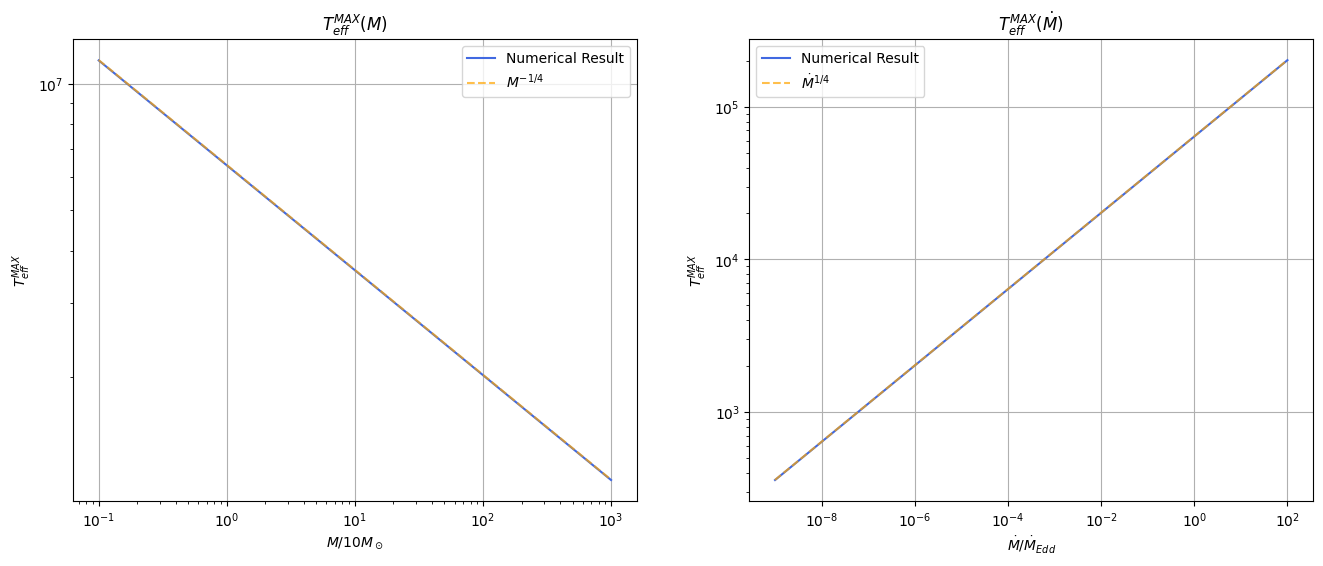

In [49]:
Mvec=np.logspace(np.log10(0.1*M),np.log10(1e3*M),100)
T_max=np.array([])

for i in range(len(Mvec)):
    Rstar_M=6*G*Mvec[i]/c**2
    L_Edd_M=4*np.pi*G*Mvec[i]*mp*c/sigmaT
    Mdot_M_Edd_M=L_Edd_M*Rstar_M/(2*eta*G*Mvec[i])
    Mdot_M=0.1*Mdot_M_Edd_M
    Rout_M=1e8*Rstar_M
    Rvec_M=np.logspace(np.log10(1.05*Rstar_M),np.log10(Rout_M),1000)
    T_max=np.append(T_max,np.max(Teff(Rvec_M,Rstar_M,Mvec[i],Mdot_M)))

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(Mvec/M,T_max, c='royalblue', label='Numerical Result')
ax1.plot(Mvec/M,(Mvec/M)**(-1/4)*6.4e6, alpha=0.7, c='orange', ls='--', label=r'$M^{-1/4}$')

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$M/10M_\odot$")
ax1.set_ylabel(r'$T_{eff}^{MAX}$')
ax1.grid()
ax1.set_title(r"$T_{eff}^{MAX}(M)$")
ax1.legend(loc='best');

T_max=np.array([])
for i in range(len(M_dot_vec)):
    T_max=np.append(T_max,np.max(Teff(Rvec_M,Rstar_M,M,M_dot_vec[i])))

ax2.plot(M_dot_vec/Mdot_Edd,T_max, c='royalblue', label='Numerical Result')
ax2.plot(M_dot_vec/Mdot_Edd,(M_dot_vec/Mdot_Edd)**(1/4)*6.4e4, alpha=0.7, c='orange', ls='--', label=r'$\dot{M}^{1/4}$')

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$\dot{M}/\dot{M}_{Edd}$")
ax2.set_ylabel(r'$T_{eff}^{MAX}$')
ax2.grid()
ax2.set_title(r"$T_{eff}^{MAX}(\dot{M})$")
ax2.legend(loc='best');

### d) Luminosity profile

$$
\frac{dL}{dlnR}=2 \pi R^2 Q^+(R) \rightarrow \int dL=2 \pi \int R Q^+(R) dR \rightarrow L=\frac{GM\dot{M}}{2R_*}
$$

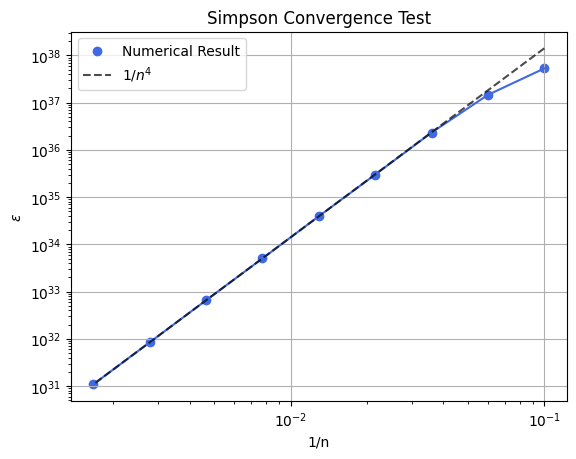

In [50]:
Mdot=0.1*Mdot_Edd
n=np.logspace(1,3,10)
integral=np.array([])
for i in range(len(n)):
    integral=np.append(integral,Simpson(Rstar,Rout,int(n[i])))

prop=1/n
plt.plot(prop[:-1],np.abs(integral[:-1]-integral[1:]),c='royalblue')
plt.scatter(prop[:-1],np.abs(integral[:-1]-integral[1:]),c='royalblue',label='Numerical Result')
plt.plot(prop[:-1],prop[:-1]**(4)*(np.abs(integral[-2]-integral[-1])/prop[-2]**4), c='k', ls='--', alpha=0.7, label=r'$1/n^4$')

plt.xscale("log")
plt.yscale("log")
plt.xlabel("1/n")
plt.ylabel(r'$\epsilon$')
plt.grid()
plt.title("Simpson Convergence Test")
plt.legend(loc='best');

True Luminosity 5.519043447751862e+38
Numerical Luminosity 5.519043266058506e+38


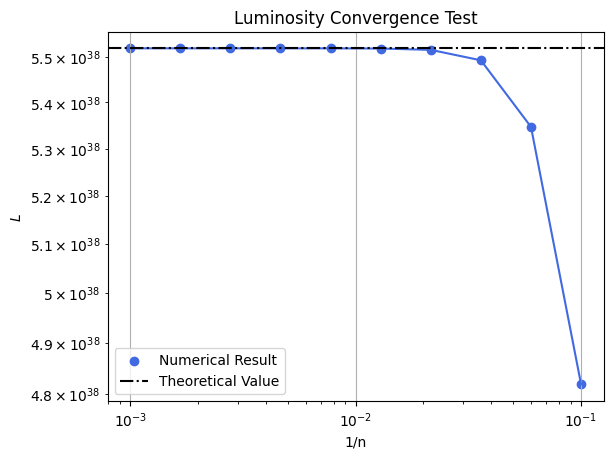

In [51]:
print("True Luminosity", Luminosity(M,Mdot,Rstar))
print("Numerical Luminosity", integral[-1])
plt.scatter(prop,integral,c='royalblue',label='Numerical Result')
plt.plot(prop,integral,c='royalblue')
plt.axhline(Luminosity(M,Mdot,Rstar), ls='-.', c='k', label="Theoretical Value")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"1/n")
plt.ylabel(r'$L$')
plt.grid()
plt.title("Luminosity Convergence Test")
plt.legend(loc='best');

# CONSERVATION

## Angular Momentum Flux

$$
\dot{J}=\dot{M} \sqrt{GMR}-G_{\nu}=\dot{M} \sqrt{GMR}-\frac{8 \pi R^2 Q^{+}}{6 \Omega_K}=\rm{constant}=\dot{M} \sqrt{GMR_*}
$$

In [52]:
def Angular_Momentum_Flux(R,Rstar,M,Mdot):
    G_nu=8*np.pi/3*R**2/2*Qplus(R,Rstar,M,Mdot)/OmegaK(R,M)
    return Mdot*np.sqrt(G*M*R)-G_nu

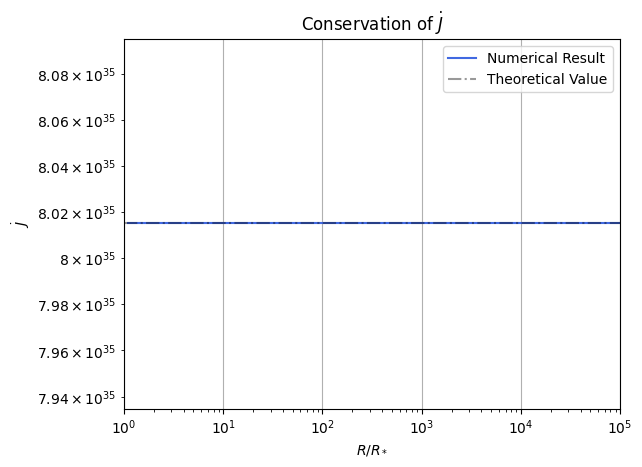

In [53]:
Jdot=Angular_Momentum_Flux(Rvec,Rstar,M,Mdot)

plt.plot(Rvec/Rstar,Jdot, label='Numerical Result', c='royalblue')
plt.axhline(Mdot*np.sqrt(G*M*Rstar), c='k', ls='-.', alpha=0.4, label='Theoretical Value')

plt.xlim(1,1e5)
plt.ylim(0.99*8.01517e35,1.01*8.01517e35)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$R/R_*$")
plt.ylabel(r'$\dot{J}$')
plt.grid()
plt.title(r"Conservation of $\dot{J}$")
plt.legend(loc='best');

# Inward Velocities

$$
\dot{M}=-2 \pi R \Sigma v(R)
$$

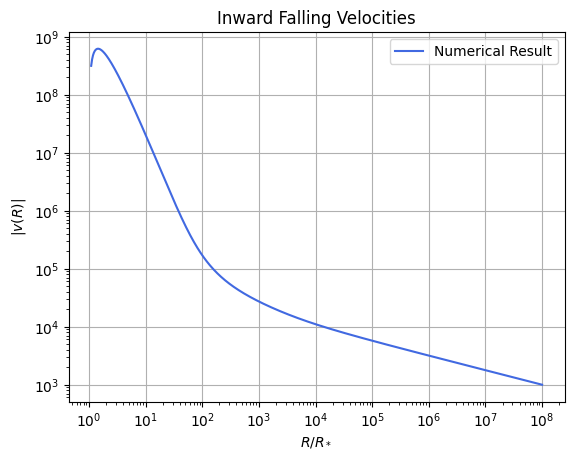

In [54]:
v=-Mdot/2/np.pi/Rvec/Sigma_vec3
plt.plot(Rvec/Rstar,np.abs(v), c='royalblue', label='Numerical Result')

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$R/R_*$")
plt.ylabel(r'$|v(R)|$')
plt.grid()
plt.title(r"Inward Falling Velocities")
plt.legend(loc='best');

# Accretion Timescale

$$
t_{acc}(R)=\frac{R}{v(R)}
$$

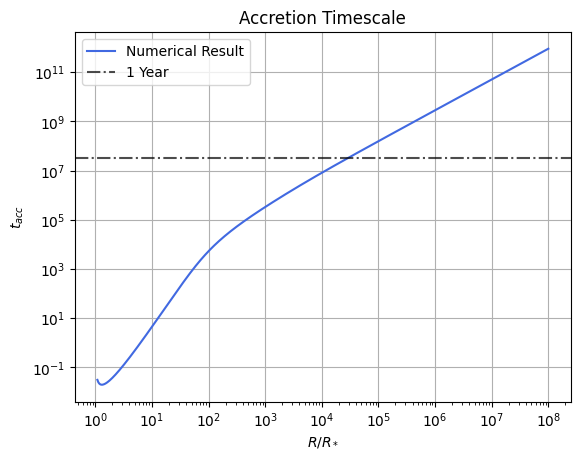

In [55]:
plt.plot(Rvec/Rstar,Rvec/-v, c='royalblue', label='Numerical Result')
plt.axhline(np.pi*1e7, c='k', ls='-.', alpha=0.7, label='1 Year')

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$R/R_*$")
plt.ylabel(r'$t_{acc}$')
plt.grid()
plt.title(r"Accretion Timescale")
plt.legend(loc='best');

## e) (Extension) Emergent Spectrum

When looking at the emergent luminosity from a Shakura Sunyaev alpha accretion disk as a function of frequency, I expect to identify three regions:

1. Rayleigh-Jeans Tail: $L_\nu \propto \nu^2$
2. Multi-colour Disk Regime: $L_\nu \propto \nu^{1/3}$
3. Wien Cutoff: $L_\nu \propto e^{-\nu/C}$

In [56]:
def dL_nu(R,Rstar,M,Mdot,nu):
    T=Teff(R,Rstar,M,Mdot)
    if (h_planck*nu)/(k*T)>700:
        return 0.0
    B=(2*h_planck*nu**3/c**2)/(np.expm1((h_planck*nu)/(k*T)))
    return np.pi*B*4*np.pi*R

In [57]:
def Simpson_BB(a,b,n,nu):
    logR=np.logspace(np.log10(a),np.log10(b),n+1)
    h=np.diff(logR)
    left=logR[:-1]
    right=logR[1:]
    m=(left+right)/2
    Q=0
    for i in range(n):
        Q+=h[i]/6*(dL_nu(left[i],Rstar,M,Mdot,nu)+dL_nu(right[i],Rstar,M,Mdot,nu)+4*dL_nu(m[i],Rstar,M,Mdot,nu))
    return Q

In [58]:
Lnu=np.array([])
nu_vec=np.logspace(11,19,100)
for nu in nu_vec:
    L_nu=Simpson_BB(1.1*Rstar,1e4*Rstar,int(1e5),nu)
    Lnu=np.append(Lnu,L_nu)

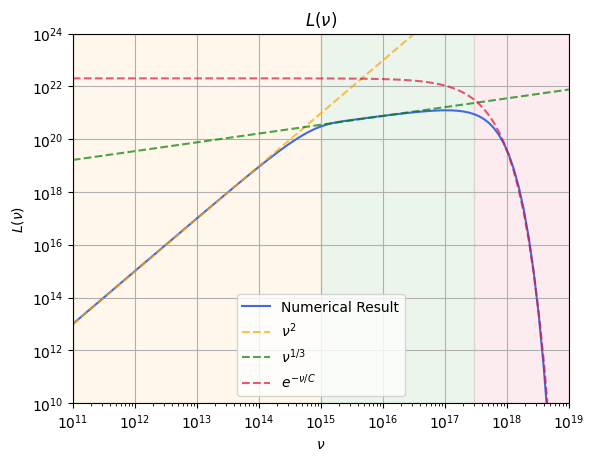

In [59]:
plt.plot(nu_vec,Lnu, c='royalblue', label='Numerical Result')
plt.plot(nu_vec,nu_vec**(2)*9.5e-10, alpha=0.7, c='orange', ls='--', label=r'$\nu^2$')
plt.plot(nu_vec,nu_vec**(1/3)*3.5e15, alpha=0.7, c='green', ls='--', label=r'$\nu^{1/3}$')
plt.plot(nu_vec,np.exp(-nu_vec/1.6e17)*2e22, alpha=0.7, c='crimson', ls='--', label=r'$e^{-\nu/C}$')

plt.axvspan(1e11, 1e15, color='orange', alpha=0.08)
plt.axvspan(1e15, 3e17, color='green', alpha=0.08)
plt.axvspan(3e17, 1e19, color='crimson', alpha=0.08)

plt.xlim(1e11,1e19)
plt.ylim(1e10,1e24)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\nu$")
plt.ylabel(r'$L(\nu)$')
plt.grid()
plt.title(r"$L(\nu)$")
plt.legend(loc='best');

We see frequencies span from $4 \times 10^{14}$, red, to $10^{14}$, soft X-rays.